<a href="https://colab.research.google.com/github/aggrimm/IEDRR_inland_lakes/blob/main/notebooks/3_lakes_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.3.1
!pip install --upgrade xgboost


In [ ]:
# setup
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import time
from sklearn import model_selection
from sklearn.preprocessing import LabelEncoder
from sklearn import datasets
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve



from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("drive/My Drive/iedrr")

#!ls

Mounted at /content/drive


In [ ]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV

from xgboost import plot_importance
from xgboost import XGBClassifier
from xgboost import XGBRegressor

import warnings
#warnings.filterwarnings("ignore")
from datetime import datetime

In [ ]:
### XGBoost model
os.chdir("final_inputs_Feb2026")


In [ ]:
os.getcwd()

'/content/drive/MyDrive/iedrr/final_inputs_Feb2026'

In [ ]:

# lake variables
#lakes_env = pd.read_csv('lakes_env.csv')
lakes_env = pd.read_csv('lakes_env_plus_15Feb2026_3.csv')
lakes_env.sort_values(by=['lagoslakeid'], inplace=True)
lakes_env.head()


,lagoslakeid,freshwater_fishing_demand,area,angler_inc,highway_distance,log_area,ramp,boat_parking,percent_natural,pop_catchment,...,great_lakes_distance,ramps_upstream,agency_all_pct,est_tn,est_tp,est_chla,lake_maxdepth_m,depth_src,buff100_publiclands_pct,lake_primaryroaddistance_m
9639,59,42874.637800,27.213375,1.021873,36.444914,1.434782,0,0,0.254252,3,...,230.868886,0,5.743050,1696.871030,99.837103,39.833622,1.267036,Hollister estimate,0.0,26552.180
28204,60,14326.134450,6.677168,0.000000,16.137855,0.824592,0,0,0.171265,21,...,120.627740,0,0.000000,1552.713054,88.245127,33.707164,2.369276,Hollister estimate,0.0,16144.136
3885,61,3029.088776,75.225304,2.692692,49.835917,1.876364,1,2,0.472203,3,...,24.182139,0,6.592440,524.102429,19.289184,6.891239,4.571777,LAGOSUS,0.0,49817.562
273,62,2472.632581,914.965958,0.972995,38.679948,2.961405,1,7,0.475751,25,...,293.665663,1,9.650734,2212.424640,154.405951,46.248581,1.218946,LAGOSUS,0.0,38669.977
3872,63,1972.588358,75.682772,0.000000,110.360198,1.878997,1,1,0.394619,0,...,53.399161,0,91.828285,462.855435,15.517198,4.976730,5.789777,LAGOSUS,0.0,110338.766


In [ ]:
len(lakes_env[lakes_env['depth_src'] != "Hollister estimate"])

9431

In [ ]:
# get summary for all columns rather than ellipsis
pd.options.display.max_columns = 2000
lakes_env.describe()

,lagoslakeid,freshwater_fishing_demand,area,angler_inc,highway_distance,log_area,ramp,boat_parking,percent_natural,pop_catchment,natureserve_lci,shorelinedevfactor,lake_lakes1ha_upstream_ha,lake_lakes1ha_upstream_n,ws_area_ha,nws_area_ha,streams_all_mperha,climate8110norm_tmax_degc,climate8110norm_tmean_degc,climate8110norm_tmin_degc,canals_mperha,nlcd_alldev_pct,nlcd_cultcrop82_pct,nlcd_allwet_pct,nlcd_wetemerg95_pct,nlcd_wetwood90_pct,shoreland_dist,lake_rsvr_probrsvr,lake_nets_damonlake_flag,net_lakes_n,nn_mean,nn_min,latitude,pop_0_4_buffer,pop_5_buffer,great_lakes_distance,ramps_upstream,agency_all_pct,est_tn,est_tp,est_chla,lake_maxdepth_m,buff100_publiclands_pct,lake_primaryroaddistance_m
count,67845.000000,67845.000000,67845.000000,67845.000000,67845.000000,67845.000000,67845.000000,67845.00000,67812.000000,6.784500e+04,67812.000000,67845.000000,67809.000000,67809.000000,6.780900e+04,6.780900e+04,67809.000000,67843.000000,67843.000000,67843.000000,67809.000000,67785.000000,67785.000000,67785.000000,67785.000000,67785.000000,67845.000000,41358.000000,16864.000000,16864.000000,6.784500e+04,67845.000000,67845.000000,5.407000e+04,6.628700e+04,67845.000000,67845.000000,67626.000000,67845.000000,67845.000000,67845.000000,66876.000000,67845.000000,67779.000000
mean,84605.348559,12959.862188,42.200159,1.689581,43.692405,0.876029,0.089675,1.20905,0.435564,3.217285e+02,30.473346,1.705880,319.307667,4.889041,1.462098e+03,5.793889e+03,6.352014,13.109713,7.408404,1.707096,0.574018,11.456558,17.622033,16.163458,4.065447,12.098011,26.945374,0.389457,0.081179,12709.702028,1.181895e+06,43699.678046,43.780505,1.119156e+03,2.716610e+04,162.222950,0.047594,23.537674,1074.864058,60.596677,19.983838,4.382410,3.473902,35336.057225
std,67830.239441,15347.581214,940.489784,10.169611,50.189049,0.529584,0.285718,8.51684,0.249167,1.011840e+04,28.277163,0.763479,8667.655487,100.303069,2.808770e+04,1.063438e+05,12.838696,2.668036,2.793070,2.956187,5.042612,20.328441,26.963268,20.896366,10.037495,17.801533,29.439631,0.331085,0.273118,15363.379382,1.993979e+05,40820.897847,2.816105,1.899679e+04,2.786574e+05,114.637624,1.229617,35.932629,509.651285,51.822993,14.668716,4.934616,18.186578,40986.612131
min,59.000000,30.012612,2.000154,0.000000,0.000000,0.301064,0.000000,0.00000,0.000000,0.000000e+00,0.000000,1.000645,0.000000,0.000000,1.612734e-02,1.612734e-02,0.000000,7.574943,2.187719,-4.175653,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,5.428529e+04,0.000000,37.062589,0.000000e+00,1.296176e-03,0.000000,0.000000,0.000000,157.967960,3.667121,1.586333,0.000000,0.000000,0.000000
25%,34912.000000,3487.289439,2.992746,0.000000,7.192764,0.476070,0.000000,0.00000,0.233851,0.000000e+00,10.428571,1.244643,0.000000,0.000000,3.034795e+01,3.112428e+01,0.000000,10.793336,4.998510,-0.947195,0.000000,1.111111,0.000000,0.990099,0.000000,0.000000,0.606061,0.074900,0.000000,453.000000,1.040542e+06,14260.597270,41.546294,8.140626e+00,3.521758e+02,62.868311,0.000000,0.000000,694.776585,24.264204,7.767564,1.647032,0.000000,6710.255000
50%,75020.000000,6764.667890,5.255457,0.000000,21.884354,0.720611,0.000000,0.00000,0.424019,2.000000e+00,21.765915,1.485545,0.000000,0.000000,8.606721e+01,9.216957e+01,0.000000,12.668215,7.005376,1.352394,0.000000,4.536862,0.258580,7.857143,0.516987,3.824948,15.416667,0.306300,0.000000,1463.000000,1.164752e+06,28624.713680,44.126886,3.076679e+01,1.305022e+03,141.685523,0.000000,0.293540,1032.664232,39.267968,14.248620,2.983958,0.000000,19634.752000
75%,114408.000000,16129.948170,13.380176,0.070644,63.921267,1.126462,0.000000,0.00000,0.626912,1.800000e+01,42.179060,1.897106,0.000000,0.000000,2.694587e+02,3.280387e+02,8.054084,14.997711,9.574358,4.111772,0.000000,9.678731,29.343629,23.308271,3.225806,17.408907,45.714286,0.682900,0.000000,32811.000000,1.315540e+06,61447.013010,46.168579,1.292703e+02,4.688892e+03,249.324135,0.000000,38.182979,1341.713472,85.270619,31.999938,5.412911,0.000000,49296.237

In [ ]:
lakes_env.isna().sum()

,0
lagoslakeid,0
freshwater_fishing_demand,0
area,0
angler_inc,0
highway_distance,0
log_area,0
ramp,0
boat_parking,0
percent_natural,33
pop_catchment,0


In [ ]:
# prep for columns that aren't taxon-specific

lakes_env = lakes_env.replace(' ', np.nan)
# impute 0s where that's the logical filler
lakes_env['pop_0_4_buffer'] = lakes_env['pop_0_4_buffer'].fillna(0)
lakes_env['pop_5_buffer'] = lakes_env['pop_5_buffer'].fillna(0)
lakes_env['agency_all_pct'] = lakes_env['agency_all_pct'].fillna(0)

# where just a few lakes are missing drop those lakes
lakes_env.dropna(subset=['streams_all_mperha'], inplace=True)
lakes_env.dropna(subset=['climate8110norm_tmax_degc'], inplace=True)
lakes_env.dropna(subset=['percent_natural'], inplace=True)
lakes_env.dropna(subset=['nlcd_cultcrop82_pct'], inplace=True)

#filt = pd.read_csv('invert_lakes_obsconn.csv')
#lakes_env = pd.merge(lakes_env, filt, on="lagoslakeid", how="left")
# for lakes with no upstream obs, use arbitrarily large number
#lakes_env['min_dist_upst'] = lakes_env['min_dist_upst'].fillna(1000)
#lakes_env.drop(columns=['nn_dist_min', 'nn_dist_mean'], inplace=True)

# mean imputation for reservoirs
lakes_env['lake_rsvr_probrsvr'] = lakes_env['lake_rsvr_probrsvr'].fillna(lakes_env['lake_rsvr_probrsvr'].mean())

# if it's a reservoir, there's a dam on it
lakes_env.loc[lakes_env['lake_rsvr_probrsvr'] == 1, 'lake_nets_damonlake_flag'] = 1
# if there's a dam on it, it's a reservoir
lakes_env.loc[lakes_env['lake_nets_damonlake_flag'] == 1, 'lake_rsvr_probrsvr'] = 1

# assume 0 for the rest
lakes_env['lake_nets_damonlake_flag'] = lakes_env['lake_nets_damonlake_flag'].fillna(0)

lakes_env['net_lakes_n'] = lakes_env['net_lakes_n'].fillna(0)


In [ ]:
# new imputer
lakes_env.drop(columns=['depth_src'], inplace=True)
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.tree import DecisionTreeRegressor
defimputer = IterativeImputer(max_iter=10, random_state=0, verbose=2)
def_lakes_env_imputed = defimputer.fit_transform(lakes_env)
def_imputed_lakes = pd.DataFrame(def_lakes_env_imputed, columns=lakes_env.columns)
'''
another option

from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=2)
knn_imputed_data = knn_imputer.fit_transform(lakes_env.iloc[0:300 , 1:])
'''

def_imputed_lakes.to_csv('lakes_env_imputed.csv')


[IterativeImputer] Completing matrix with shape (67783, 44)
[IterativeImputer] Ending imputation round 1/10, elapsed time 14.72
[IterativeImputer] Change: 94066.42415046901, scaled tolerance: 10992.995949999999 
[IterativeImputer] Ending imputation round 2/10, elapsed time 26.64
[IterativeImputer] Change: 200.29392008294235, scaled tolerance: 10992.995949999999 
[IterativeImputer] Early stopping criterion reached.


In [ ]:
import geopandas as gpd

In [ ]:
# cut down to the lakes we've been providing model values for
shp = gpd.read_file("/content/drive/My Drive/iedrr/web_lakes_wgs84.shp")

shp.rename(
    columns={'lagoslakei': 'lagoslakeid'},
    inplace=True
  )
shp = shp[['lagoslakeid', 'geometry']]
shp.drop_duplicates(subset=['lagoslakeid'], inplace=True)

In [ ]:
#lakes_env = lakes_env[lakes_env['lagoslakeid'].isin(shp['lagoslakei'])]
lakes_env = def_imputed_lakes.merge(shp, on='lagoslakeid', how='right')

gdf = gpd.GeoDataFrame(lakes_env, geometry='geometry', crs="EPSG:4326")
utm = gdf.estimate_utm_crs()
lakes_env = gdf.to_crs(utm)

In [ ]:
copy_lakes_env = lakes_env.copy()

In [ ]:
lakes_env.drop(columns=['nn_mean', 'nn_min'], inplace=True)


In [ ]:
len(lakes_env)

67872

In [ ]:
#lakes_env.drop(['nn_min', 'nn_mean', 'Unnamed: 0', 'depth_src', 'Permanent_'], axis=1, inplace=True)
for taxon in ['plant', 'fish', 'invert']:
  print(taxon)
  obsfile = pd.read_csv('/content/drive/My Drive/iedrr/speciesobs_20260208/'+taxon+'_obs_allsources_flagged_20260208.csv')
  obsrecs = gpd.GeoDataFrame(obsfile, geometry=gpd.points_from_xy(obsfile['lon_dec'], obsfile['lat_dec']), crs="EPSG:4326")
  obsrecs = obsrecs.to_crs(utm)
  # don't train model on obs in eval set (2024-)
  obsrecs['obs_date'] = pd.to_datetime(obsrecs['obs_date'])
  obsrecs = obsrecs[obsrecs['obs_date'].dt.year < 2024]
  spp_dists_list = []
  for spp in obsrecs['sci_name'].unique():
    print(spp)
    sp_spec = obsrecs[obsrecs['sci_name'] == spp]
    #print(spp, len(sp_spec))
    nearest_feature = gpd.sjoin_nearest(lakes_env, sp_spec, how="left", distance_col="distance")
    #spdist = nearest_feature['distance'].min()
    spdists = nearest_feature[['lagoslakeid','distance']]
    #print(spdist)
    spp_dists_list.append(spdists)
  combined_dists = pd.concat(spp_dists_list, ignore_index=True)
  result = combined_dists.groupby('lagoslakeid')['distance'].agg(['min', 'mean'])

  result.rename(
    columns={'min': 'nn_min', 'mean': 'nn_mean'},
    inplace=True
  )

  # to km
  result['nn_min'] = result['nn_min'] / 1000
  result['nn_mean'] = result['nn_mean'] / 1000
  result = result.reset_index()
  print(len(lakes_env))
  print(len(lakes_env['lagoslakeid'].unique()))
  lakes_env_taxon = lakes_env.merge(result, on='lagoslakeid', how='left')
  print(len(lakes_env_taxon))
  lakes_env_taxon.drop(columns=['geometry'], inplace=True)
  lakes_env_taxon = lakes_env_taxon.loc[:, ~lakes_env_taxon.columns.str.contains('Unnamed')]
  lakes_env_taxon.dropna(inplace=True)

  # currently getting spp_upst and	min_dist_upst from filt - check issue with duplicate lakeids
  filt = pd.read_csv(taxon+'_lakes_obsconn.csv')
  # temp fix
  filt = filt.groupby('lagoslakeid').agg({'spp_upst': 'max', 'min_dist_upst': 'min'})
  print(len(lakes_env_taxon))
  lakes_env_taxon = pd.merge(lakes_env_taxon, filt, on="lagoslakeid", how="left")
  print(len(lakes_env_taxon))
  # for lakes with no upstream obs, use arbitrarily large number
  lakes_env_taxon['min_dist_upst'] = lakes_env_taxon['min_dist_upst'].fillna(1000)
  lakes_env_taxon['spp_upst'] = lakes_env_taxon['spp_upst'].fillna(0)
  print(len(lakes_env_taxon))
  lakes_env_taxon.to_csv('lakes_env_'+taxon+'.csv')
  print(taxon,"saved")






plant
Trapa natans
Nasturtium officinale
Marsilea quadrifolia
Cabomba caroliniana
Hydrocharis morsus-ranae
Myriophyllum aquaticum
Najas minor
Ludwigia grandiflora
Nitellopsis obtusa
Pistia stratiotes
Pontederia crassipes
Callitriche stagnalis
Hydrilla verticillata
Egeria densa
Ludwigia peploides
Nelumbo nucifera
Spirodela punctata
Ludwigia hexapetala
Marsilea mutica
67872
67872
67872
67783
67783
67783
plant saved
fish
Osmerus mordax
Tinca tinca
Gymnocephalus cernua
Proterorhinus semilunaris
Neogobius melanostomus
Misgurnus anguillicaudatus
Channa argus
67872
67872
67872
67783
67783
67783
fish saved
invert
Bithynia tentaculata
Corbicula fluminea
Bythotrephes longimanus
Dreissena polymorpha
Dreissena bugensis
Cercopagis pengoi
Potamopyrgus antipodarum
Hemimysis anomala
Eriocheir sinensis
Melanoides tuberculata
67872
67872
67872
67783
67783
67783
invert saved


In [ ]:
len(lakes_env_taxon['lagoslakeid'].unique())

67783

In [ ]:
for taxon in ['plant', 'fish', 'invert']:
  nnfile = '/content/drive/MyDrive/iedrr/new_nn_dists_'+taxon+'_20260208.csv'
  bg_file = '/content/drive/MyDrive/iedrr/bg_nn_dists_'+taxon+'_20260208.csv'

plant
invaded lakes:  969
background lakes:  969
All have the same columns
training plant model
Fitting 4 folds for each of 2880 candidates, totalling 11520 fits
[0]	validation_0-logloss:0.63582	validation_1-logloss:0.69271
[1]	validation_0-logloss:0.59559	validation_1-logloss:0.66518
[2]	validation_0-logloss:0.56022	validation_1-logloss:0.64213
[3]	validation_0-logloss:0.52986	validation_1-logloss:0.62219
[4]	validation_0-logloss:0.51051	validation_1-logloss:0.61423
[5]	validation_0-logloss:0.48990	validation_1-logloss:0.59744
[6]	validation_0-logloss:0.47157	validation_1-logloss:0.58778
[7]	validation_0-logloss:0.45574	validation_1-logloss:0.58026
[8]	validation_0-logloss:0.44054	validation_1-logloss:0.57077
[9]	validation_0-logloss:0.42685	validation_1-logloss:0.56566
[10]	validation_0-logloss:0.41730	validation_1-logloss:0.55667
[11]	validation_0-logloss:0.40727	validation_1-logloss:0.55421
[12]	validation_0-logloss:0.39878	validation_1-logloss:0.54790
[13]	validation_0-logloss:0.3

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [14:21:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round", "verbose_eval" } are not used.

  self.starting_round = model.num_boosted_rounds()


plant  finished
Best Parameters:
{'colsample_bytree': 0.5, 'eta': 0.15, 'gamma': 0.4, 'max_depth': 4, 'min_child_weight': 3}
roc_auc_score: 0.8916666666666666
XGBoosting with GridSearch:
> Accuracy on training data = 0.9213
> Accuracy on validation data = 0.8816


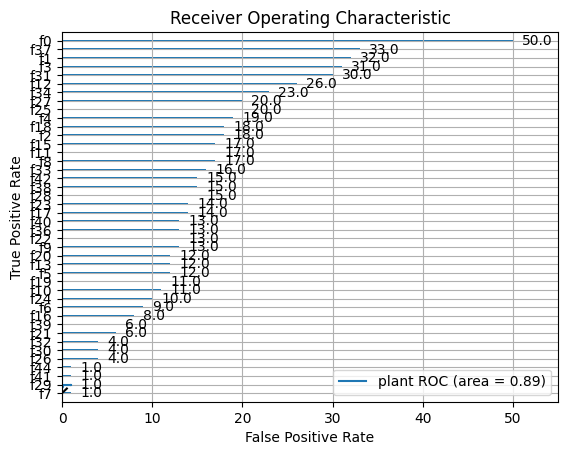

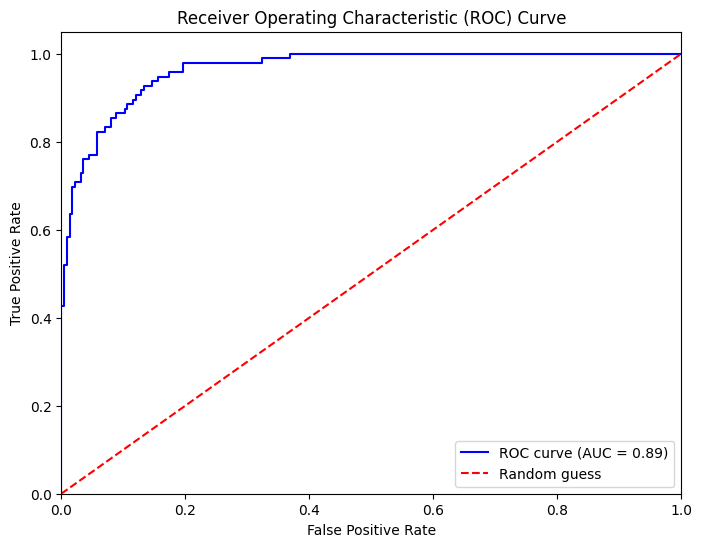

time:  4.897265307108561  min
plant done
fish
invaded lakes:  179
background lakes:  179
All have the same columns
training fish model
Fitting 4 folds for each of 2880 candidates, totalling 11520 fits
[0]	validation_0-logloss:0.67665	validation_1-logloss:0.73567
[1]	validation_0-logloss:0.66325	validation_1-logloss:0.72730
[2]	validation_0-logloss:0.64961	validation_1-logloss:0.71587
[3]	validation_0-logloss:0.63801	validation_1-logloss:0.71003
[4]	validation_0-logloss:0.62629	validation_1-logloss:0.69829
[5]	validation_0-logloss:0.61591	validation_1-logloss:0.69273
[6]	validation_0-logloss:0.60619	validation_1-logloss:0.68391
[7]	validation_0-logloss:0.59547	validation_1-logloss:0.67505
[8]	validation_0-logloss:0.58706	validation_1-logloss:0.67254
[9]	validation_0-logloss:0.57949	validation_1-logloss:0.66490
[10]	validation_0-logloss:0.56979	validation_1-logloss:0.65727
[11]	validation_0-logloss:0.56199	validation_1-logloss:0.65172
[12]	validation_0-logloss:0.55532	validation_1-loglos

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [14:22:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round", "verbose_eval" } are not used.

  self.starting_round = model.num_boosted_rounds()


[51]	validation_0-logloss:0.36835	validation_1-logloss:0.53932
[52]	validation_0-logloss:0.36456	validation_1-logloss:0.53916
[53]	validation_0-logloss:0.36113	validation_1-logloss:0.53821
[54]	validation_0-logloss:0.35787	validation_1-logloss:0.53680
[55]	validation_0-logloss:0.35509	validation_1-logloss:0.53412
[56]	validation_0-logloss:0.35311	validation_1-logloss:0.53299
[57]	validation_0-logloss:0.35076	validation_1-logloss:0.53276
[58]	validation_0-logloss:0.34868	validation_1-logloss:0.53065
[59]	validation_0-logloss:0.34499	validation_1-logloss:0.53094
[60]	validation_0-logloss:0.34196	validation_1-logloss:0.53119
[61]	validation_0-logloss:0.33966	validation_1-logloss:0.53051
[62]	validation_0-logloss:0.33633	validation_1-logloss:0.52601
[63]	validation_0-logloss:0.33367	validation_1-logloss:0.52360
[64]	validation_0-logloss:0.33068	validation_1-logloss:0.52420
[65]	validation_0-logloss:0.32882	validation_1-logloss:0.52316
[66]	validation_0-logloss:0.32608	validation_1-logloss:

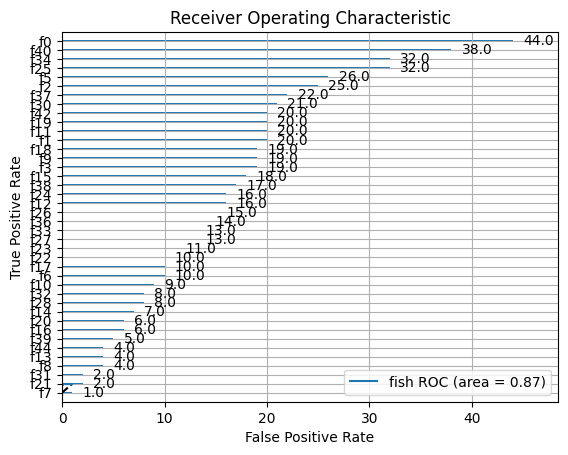

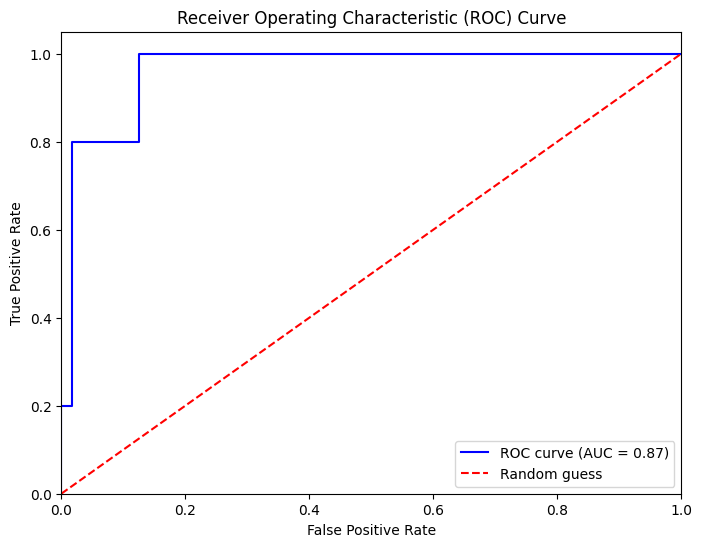

time:  1.2257431387901305  min
fish done
invert
invaded lakes:  1192
background lakes:  1192
All have the same columns
training invert model
Fitting 4 folds for each of 2880 candidates, totalling 11520 fits


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [14:29:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round", "verbose_eval" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.62607	validation_1-logloss:0.66653
[1]	validation_0-logloss:0.57540	validation_1-logloss:0.62907
[2]	validation_0-logloss:0.53592	validation_1-logloss:0.60172
[3]	validation_0-logloss:0.50399	validation_1-logloss:0.58336
[4]	validation_0-logloss:0.47606	validation_1-logloss:0.56989
[5]	validation_0-logloss:0.44994	validation_1-logloss:0.55446
[6]	validation_0-logloss:0.42830	validation_1-logloss:0.54322
[7]	validation_0-logloss:0.41017	validation_1-logloss:0.53651
[8]	validation_0-logloss:0.39316	validation_1-logloss:0.52766
[9]	validation_0-logloss:0.37648	validation_1-logloss:0.52065
[10]	validation_0-logloss:0.36210	validation_1-logloss:0.51671
[11]	validation_0-logloss:0.35135	validation_1-logloss:0.51426
[12]	validation_0-logloss:0.34071	validation_1-logloss:0.50951
[13]	validation_0-logloss:0.32977	validation_1-logloss:0.50803
[14]	validation_0-logloss:0.32189	validation_1-logloss:0.50468
[15]	validation_0-logloss:0.31396	validation_1-logloss:0.50159
[1

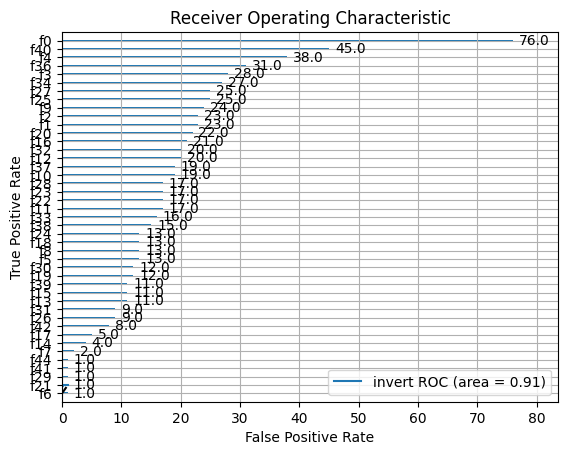

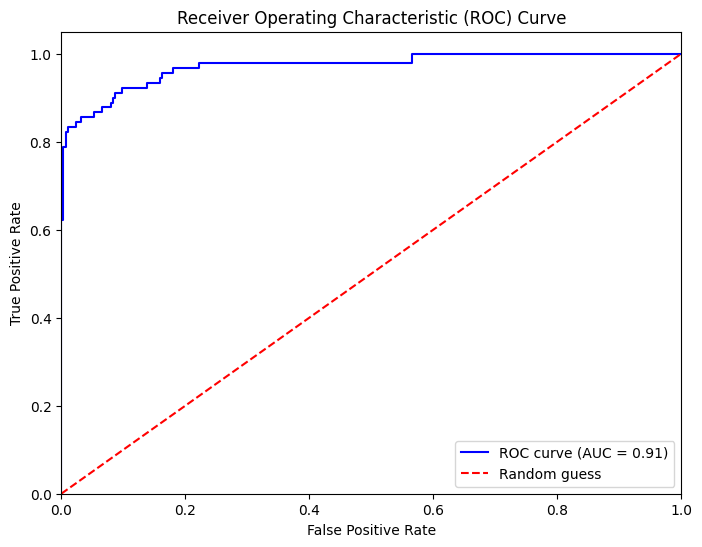

time:  6.394285813967387  min
invert done


In [ ]:
featimp_dct = {} # dictionary of feature importance values for each taxon
models_dct = {} # dictionary of taxon models

testdata_dct = {}
X_train_last_dct = {}
Xfull_dct = {}

origs = []
indatas = []

for taxon in ['plant', 'fish', 'invert']:

  lakes_env_imputed = pd.read_csv('lakes_env_'+taxon+'.csv')
  lakes_env_imputed.dropna(inplace=True)

  # reorder so that column order will match training data
  nn_min = lakes_env_imputed.pop('nn_min')
  nn_mean = lakes_env_imputed.pop('nn_mean')
  # Insert them back at the desired locations
  # The index for 'c' will shift after inserting 'b', so we use updated indices
  lakes_env_imputed.insert(2, 'nn_min', nn_min)
  lakes_env_imputed.insert(3, 'nn_mean', nn_mean)

  searchfor = ['Unnamed', 'Permanent']
  regstr = '|'.join(searchfor)
  lakes_env_imputed = lakes_env_imputed.loc[:, ~lakes_env_imputed.columns.str.contains(regstr)]

  #lakes_env_imputed.drop(['Unnamed: 0'], axis=1, inplace=True)
  orig = lakes_env_imputed.copy()

  # main model

  print(taxon)
  program_time = time.time()
  # for training data drop the current-day nearest neighbor distances and get distances from obs date
  nnfile = '/content/drive/MyDrive/iedrr/new_nn_dists_'+taxon+'_20260208.csv'
  df_nn = pd.read_csv(nnfile) # df_nn is already time-ordered
  df_nn['obs_date'] = pd.to_datetime(df_nn['obs_date'])
  df_nn['year'] = df_nn['obs_date'].dt.year
  df_nn['inv'] = 1
  df_nn = df_nn[['lagoslakeid', 'year', 'inv', 'nn_min', 'nn_mean']]
  print('invaded lakes: ', len(df_nn))
  bg_file = '/content/drive/MyDrive/iedrr/bg_nn_dists_'+taxon+'_20260208.csv'
  df_bg = pd.read_csv(bg_file)
  df_bg['inv'] = 0
  df_bg = df_bg[['lagoslakeid', 'year', 'inv', 'nn_min', 'nn_mean']]
  print('background lakes: ', len(df_bg))




  '''
  lakes_inv = pd.read_csv(taxon+'_lakes_inv_20260208.csv')
  print('invaded lakes: ', len(lakes_inv))

  lakes_bg = pd.read_csv(taxon+'_lakes_bg_20250118.csv')
  # confirm no invaded lakes are potential bg lakes
  lakes_bg = lakes_bg[~lakes_bg['lagoslakeid'].isin(lakes_inv['lagoslakeid'])]
  lakes_bg_sampled = []
  # sample from pseudoabsence lakes by temporal fold
  for fold in lakes_inv.fold.unique():
    flen = lakes_inv['fold'].value_counts()[fold]
    #print('invaded lakes in fold ', fold, ':', flen)
    lakes_bg_n = lakes_bg[lakes_bg['fold'] == fold]
    #print('potential background lakes: ', len(lakes_bg_n))
    # randomly sample without replacement
    s = lakes_bg_n.sample(n=flen, replace=False, random_state=1985)
    lakes_bg_sampled.append(s)
  lakes_bg_sampled = pd.concat(lakes_bg_sampled)
  print('background lakes: ', len(lakes_bg_sampled))
  '''

  lakes_env_imputed_join = lakes_env_imputed.drop(columns=['nn_min', 'nn_mean'])
  inv_comb = df_nn.merge(lakes_env_imputed_join, on='lagoslakeid', how='left')
  #print(len(inv_comb[inv_comb['nn_dist_min'] == 0]))


  fulldataset = lakes_env_imputed.values
  Xfull = fulldataset[:,1:]
  Xfull_dct[taxon] = Xfull

  #inv_comb = inv_comb.drop(columns=['lagoslakeid'])

  bg_comb = df_bg.merge(lakes_env_imputed_join, on='lagoslakeid')

  #bg_comb = bg_comb.drop(columns=['Unnamed: 0'])


  if set(inv_comb.columns) == set(bg_comb.columns):
      print('All have the same columns')
        # create variable for invaded/not
      #inv_comb.insert(0, 'Y', 1) # fixed
      #bg_comb.insert(0, 'Y', 0)

      # merge presence and background data
      indata = pd.concat([inv_comb, bg_comb], axis=0)
      #indata = indata.dropna()

      #sort by date
      indata = indata.sort_values(by='year')
      indata = indata.reset_index(drop=True)

      # split off most recent years as test data
      thisyear = datetime.now().year
      threshold_year = thisyear - 3
      testdata_dct[taxon] = indata.loc[indata['year'] > threshold_year]
      testdata = testdata_dct[taxon].reset_index(drop=True)
      testdata = testdata.values
      X_validation = testdata[:,3:]
      y_validation = testdata[:,2]
      indata = indata.loc[indata['year'] <= threshold_year]

      # reset index
      indata = indata.reset_index(drop=True)
      indatas.append(indata)
      dataset = indata.values
      X = dataset[:,3:]
      y = dataset[:,2]

      seed=1985
      # split obs for cross-validation to correspond with folds
      n_splits=4
      tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=n_splits, test_size=round(len(X)/(n_splits+1)))
      rmse_scores = []

      #X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state=seed)

      #test_size = 0.2 # how much to split off as test data\
      #folds = indata.groupby(indata.fold).groups
      #fmax = indata['fold'].max()
      #cv = [(list(range(0, fmax-1)), [fmax])]

      #X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=test_size, random_state=seed)
      # train model
      # takes 20 min
      print('training '+taxon+' model')
      #xgb_grid = XGBClassifier(objective= 'binary:logistic', early_stopping_rounds = 10, eval_metric = "rmse", verbose_eval = True)
      xgb_grid = XGBClassifier(objective= 'binary:logistic', num_boost_round=50, early_stopping_rounds = 10, verbose_eval = True)
      #clf = xgb.XGBClassifier()

      parameters = {
          "eta"    : [0.05, 0.10, 0.15, 0.20] ,
          "max_depth"        : [ 3, 4, 5, 6, 8, 10],
          "min_child_weight" : [ 1, 3, 5, 7 ],
          "gamma"            : [ 0.1, 0.2 , 0.3, 0.4, 0.5, 0.8],
          "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7, 0.9],}

      grid_search = GridSearchCV(
          estimator=xgb_grid,
          param_grid=parameters,
          scoring = 'neg_log_loss',
          n_jobs = -1,
          cv = tscv,
          verbose=1)

      xgb_grid_model = grid_search.fit(X, y,  eval_set=[(X, y), (X_validation, y_validation)])

      print(taxon, " finished")
      print('Best Parameters:')
      print(xgb_grid_model.best_params_)
      featimp_dct[taxon] = [xgb_grid_model.best_estimator_.feature_importances_]
      models_dct[taxon] = xgb_grid_model
      xgb.plot_importance(xgb_grid_model.best_estimator_)
      # Get final training and test set
      n_samples = len(X)                            # this is how test_size (s)
      s = n_samples//(n_splits + 1)                      # is evaluated internally

      X_train_last, X_test_last = X[ :-s], X[-s: ]
      y_train_last, y_test_last = y[ :-s], y[-s: ]
      X_train_last_dct[taxon] = X_train_last
      # Calculate Area under the curve
      preds_train = xgb_grid_model.predict(X_train_last)
      preds_test = xgb_grid_model.predict(X_test_last)
      roc_auc = roc_auc_score(y_test_last, preds_test)
      print("roc_auc_score:",roc_auc)
      print('XGBoosting with GridSearch:\n> Accuracy on training data = {:.4f}\n> Accuracy on validation data = {:.4f}'.format(
          accuracy_score(y_true=y_train_last, y_pred=preds_train),
          accuracy_score(y_true=y_test_last, y_pred=preds_test)
      ))

      y_pred_prob = xgb_grid_model.predict_proba(X_test_last)[::,1] # modeled probability of invasion
      # Compute False positive rate, and True positive rate
      fpr , tpr, thresholds = roc_curve(y_test_last, y_pred_prob)
      # plot the computed values
      plt.plot([0,1],[0,1], 'k--')
      plt.plot(fpr, tpr, label= '%s ROC (area = %0.2f)' % (taxon, roc_auc))
      plt.legend()
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')
      plt.title('Receiver Operating Characteristic')
      plt.show()

      plt.figure(figsize=(8, 6))
      plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
      plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
      plt.xlim([0.0, 1.0])
      plt.ylim([0.0, 1.05])
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')
      plt.title('Receiver Operating Characteristic (ROC) Curve')
      plt.legend(loc="lower right")
      plt.show()

      # get predictions for all lakes
      pred_p = xgb_grid_model.predict_proba(Xfull)[::,1]
      df = pd.DataFrame(pred_p)
      df = df.rename(columns={0: taxon+"risk"})
      df[taxon+'_pred'] = xgb_grid_model.predict(Xfull)
      # calibrate probabilities
      cccv = CalibratedClassifierCV(xgb_grid_model, cv='prefit')
      cccv.fit(X_validation, y_validation)
      df[taxon+'_adj_risk'] = cccv.predict_proba(Xfull)[:,1]

      orig = orig.join(df)
      #orig = orig.drop(columns=[0])
      #orig = orig.rename(columns={0: taxon+"risk"})
      #orig.head()
      elapsed = time.time() - program_time
      print("time: ", elapsed/60, " min")


  else:
      print('err: inv and bg have different columns')
  print(taxon,'done')
  orig.to_csv('risksout_upd_feb2026_fixed_3_'+taxon+'.csv', index=False)
  origs.append(orig)

In [ ]:
origs[0]

,lagoslakeid,nn_min,nn_mean,freshwater_fishing_demand,area,angler_inc,highway_distance,log_area,ramp,boat_parking,...,est_tp,est_chla,lake_maxdepth_m,buff100_publiclands_pct,lake_primaryroaddistance_m,spp_upst,min_dist_upst,plantrisk,plant_pred,plant_adj_risk
0,34183.0,24.327214,267.729110,2134.251778,8.112577,0.0,53.686859,0.909159,0.0,0.0,...,17.236027,5.067051,2.267596,0.0,53691.124,0.0,1000.0,0.895709,1,0.671730
1,86269.0,7.813774,185.554483,62089.935180,3.332363,1.0,10.849577,0.522752,0.0,0.0,...,48.995725,19.614966,4.606555,0.0,10825.853,0.0,1000.0,0.889710,1,0.665669
2,21668.0,4.580613,225.187822,4141.168058,3.255663,0.0,6.005683,0.512639,0.0,0.0,...,94.606550,28.587397,2.897303,0.0,5930.594,0.0,1000.0,0.926341,1,0.701765
3,42727.0,5.531648,225.579238,4141.168058,4.449349,0.0,7.485048,0.648296,0.0,0.0,...,90.601513,27.686766,3.375011,0.0,7411.013,0.0,1000.0,0.892842,1,0.668841
4,106840.0,3.172630,237.945408,7251.678993,6.271723,0.0,15.449810,0.797387,0.0,0.0,...,21.328758,7.141948,5.285180,0.0,15444.653,0.0,1000.0,0.960774,1,0.733556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67778,44652.0,20.112002,567.052843,2108.578193,82.137173,0.0,12.038222,1.914540,0.0,0.0,...,44.105483,27.917524,6.789350,0.0,12045.900,0.0,1000.0,0.950437,1,0.724242
67779,9572.0,11.896132,565.455244,4043.552190,3.458002,0.0,0.016217,0.538825,0.0,0.0,...,251.629718,57.197265,0.397178,0.0,20.882,0.0,1000.0,0.954750,1,0.728152
67780,11066.0,17.145532,560.230950,2998.344297,9.596444,0.0,12.235042,0.982110,0.0,0.0,...,254.701098,64.221461,1.911900,0.0,12241.121,0.0,1000.0,0.940644,1,0.715234
67781,110761.0,17.463997,555.338992,2629.603305,2.304008,0.0,11.939562,0.362484,0.0,0.0,...,196.929939,56.366898,1.955130,0.0,11933.785,0.0,1000.0,0.941422,1,0.715956


In [ ]:
plant_risks = origs[0].copy()

fish_risks = origs[1][['nn_min', 'nn_mean', 'fishrisk', 'fish_pred', 'fish_adj_risk']].copy()
invert_risks = origs[2][['nn_min', 'nn_mean', 'invertrisk', 'invert_pred', 'invert_adj_risk']].copy()

In [ ]:
# rename guild-specific nns for combined table
plant_risks.rename(
    columns={'nn_min': 'nn_min_plant', 'nn_mean': 'nn_mean_plant'},
    inplace=True
  )

fish_risks.rename(
    columns={'nn_min': 'nn_min_fish', 'nn_mean': 'nn_mean_fish'},
    inplace=True
  )

invert_risks.rename(
    columns={'nn_min': 'nn_min_invert', 'nn_mean': 'nn_mean_invert'},
    inplace=True
  )

In [ ]:
merged_df = plant_risks.join(fish_risks)
merged_df = merged_df.join(invert_risks)

In [ ]:
shp = gpd.read_file("/content/drive/My Drive/iedrr/web_lakes_wgs84.shp")

shp.rename(
    columns={'lagoslakei': 'lagoslakeid'},
    inplace=True
  )
lake_states = shp[['lagoslakeid', 'lake_mapst']]
### adjust raw risk distribution for each state, MN in particular is a problem
#risk = pd.read_csv('risks_out.csv') # copy of risksout with an adjusted state field (lake_mapstate), should write that into the script
risk = pd.merge(merged_df, lake_states, on="lagoslakeid", how="left")



In [ ]:
# make distributions more useful for management while keeping relative values
risk['plantrisk_rev'] = risk['plantrisk'] ** 6
risk['invertrisk_rev'] = risk['invertrisk'] ** 4
risk['fishrisk_rev'] = risk['fishrisk']

<Axes: xlabel='plantrisk_rev', ylabel='plant_adj_risk'>

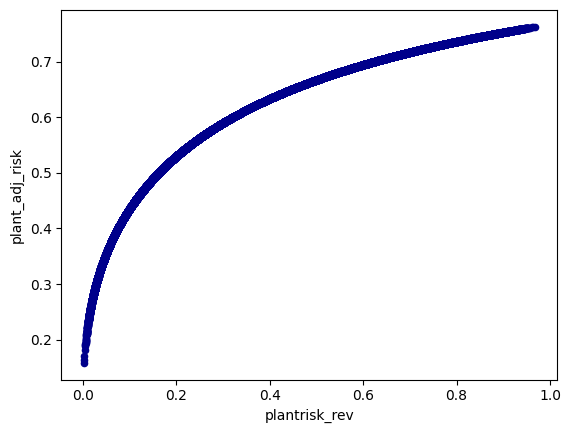

In [ ]:
risk.plot.scatter(x="plantrisk_rev", y="plant_adj_risk", c="DarkBlue")

<Axes: xlabel='invertrisk_rev', ylabel='invert_adj_risk'>

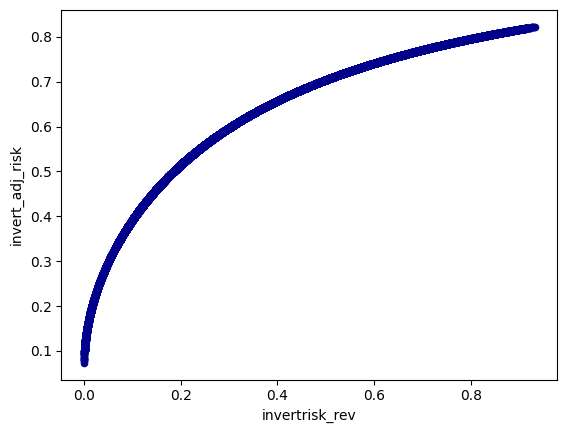

In [ ]:
risk.plot.scatter(x="invertrisk_rev", y="invert_adj_risk", c="DarkBlue")

<Axes: xlabel='fishrisk_rev', ylabel='fish_adj_risk'>

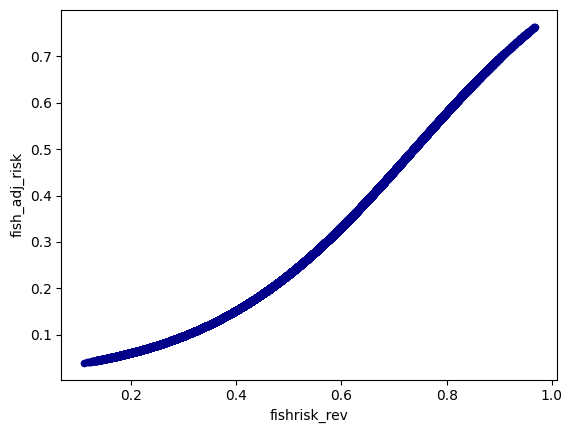

In [ ]:
risk.plot.scatter(x="fishrisk_rev", y="fish_adj_risk", c="DarkBlue")

In [ ]:
risk.to_csv('risksout_upd_feb2026_states_20Feb.csv', index=False)

plant


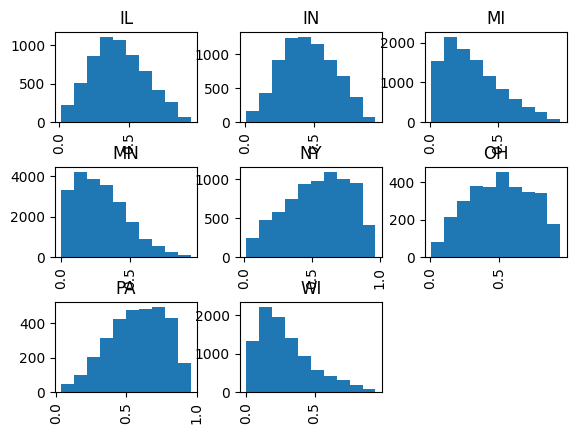

fish


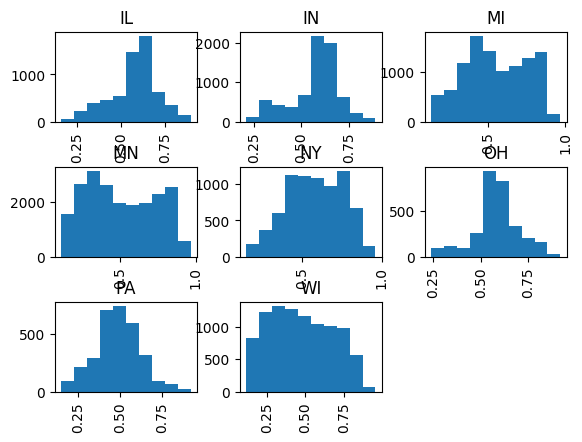

invert


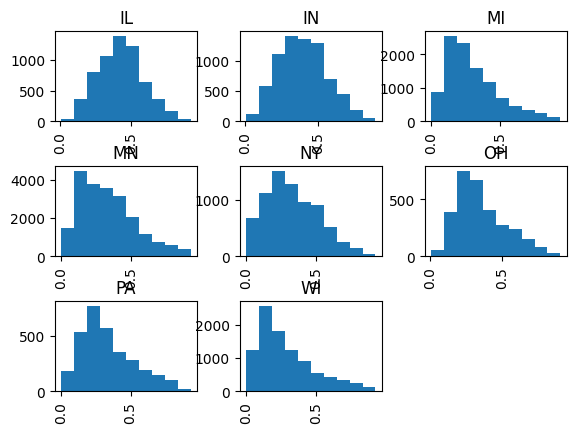

In [ ]:
for taxon in ['plant', 'fish', 'invert']:
  print(taxon)
  histplot = risk.hist(taxon+'risk_rev', by='lake_mapst')
  plt.show()

In [ ]:
risk['fishrisk_rev'] = risk['fishrisk'] ** 2

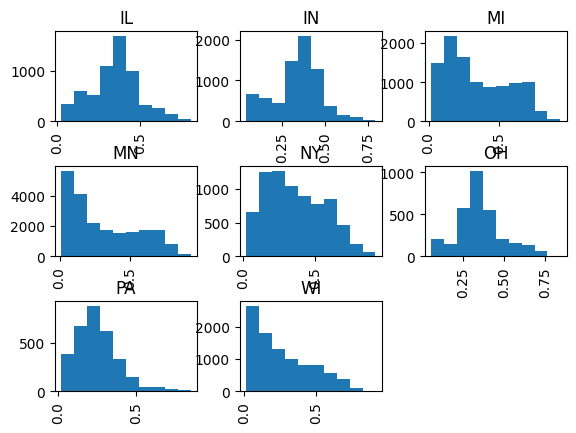

In [ ]:
histplot = risk.hist('fishrisk_rev', by='lake_mapst')
plt.show()

plant


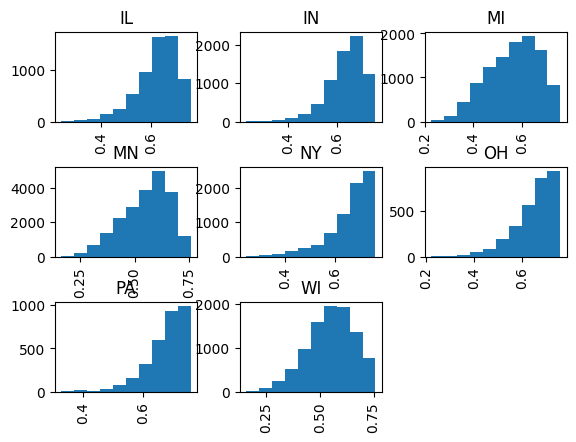

fish


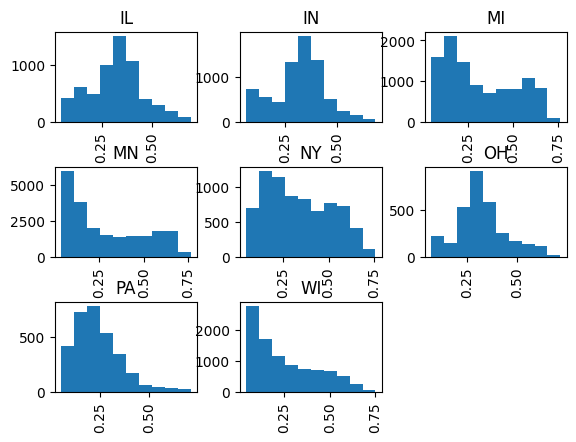

invert


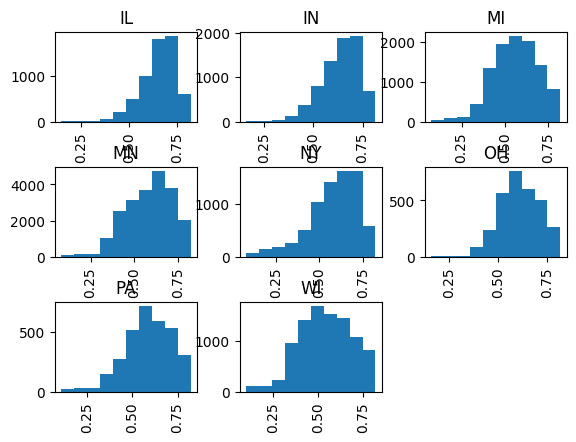

In [ ]:
#import matplotlib.pyplot as plt

for taxon in ['plant', 'fish', 'invert']:
  print(taxon)
  histplot = risk.hist(taxon+'_adj_risk', by='lake_mapst')
  plt.show()

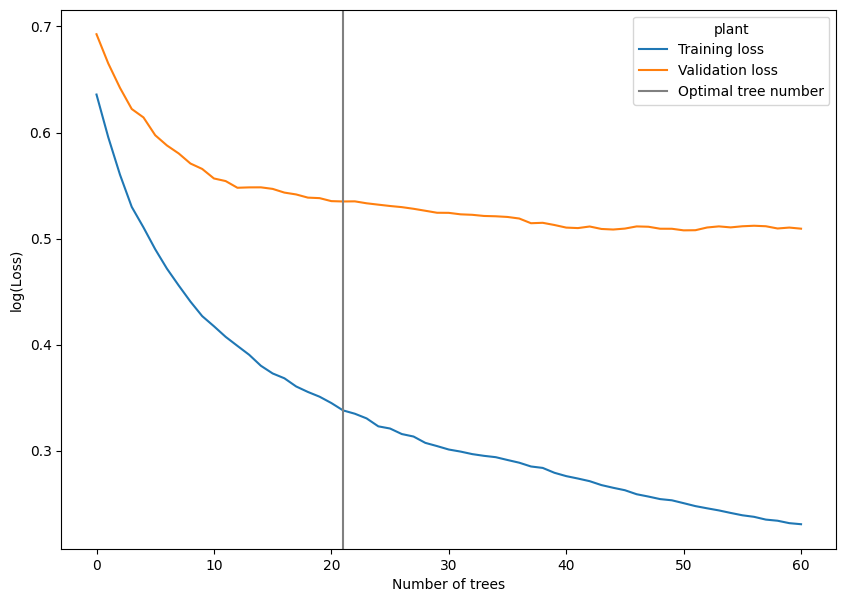

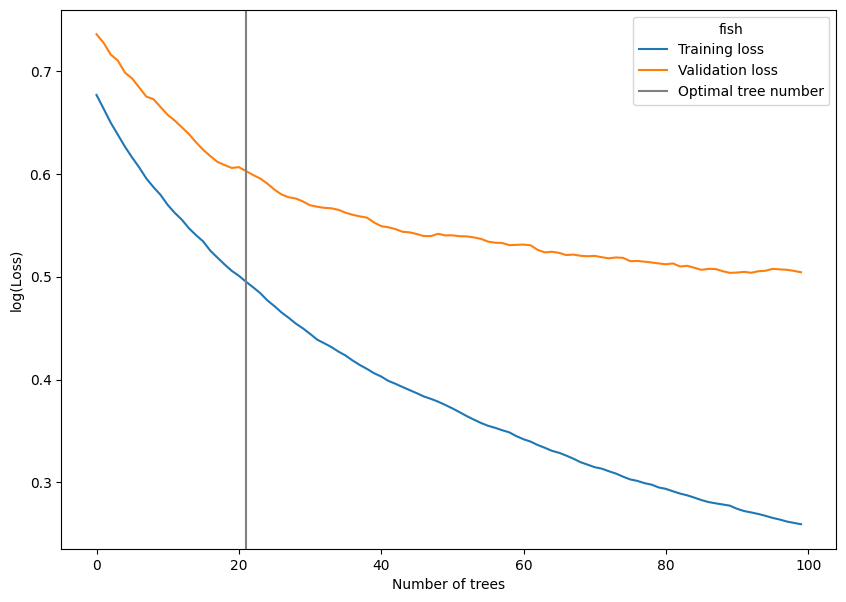

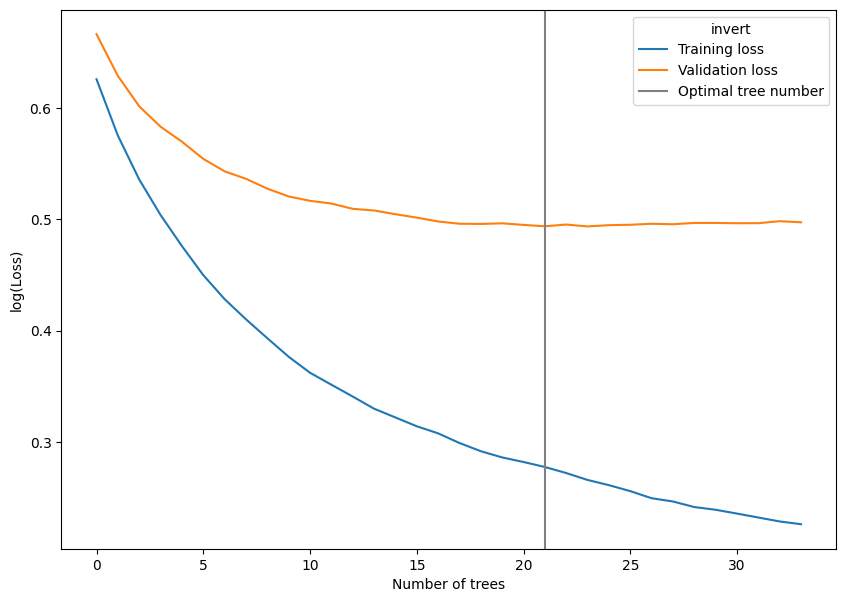

In [ ]:
for taxon in ['plant', 'fish', 'invert']:
  model = models_dct[taxon]
  results = model.best_estimator_.evals_result()


  plt.figure(figsize=(10,7))
  plt.plot(results["validation_0"]["logloss"], label="Training loss")
  plt.plot(results["validation_1"]["logloss"], label="Validation loss")
  plt.axvline(21, color="gray", label="Optimal tree number")
  plt.xlabel("Number of trees")
  plt.ylabel("log(Loss)")
  plt.legend(title=taxon)

In [ ]:
indatas[i].columns

Index(['lagoslakeid', 'year', 'inv', 'nn_min', 'nn_mean',
       'freshwater_fishing_demand', 'area', 'angler_inc', 'highway_distance',
       'log_area', 'ramp', 'boat_parking', 'percent_natural', 'pop_catchment',
       'natureserve_lci', 'shorelinedevfactor', 'lake_lakes1ha_upstream_ha',
       'lake_lakes1ha_upstream_n', 'ws_area_ha', 'nws_area_ha',
       'streams_all_mperha', 'climate8110norm_tmax_degc',
       'climate8110norm_tmean_degc', 'climate8110norm_tmin_degc',
       'canals_mperha', 'nlcd_alldev_pct', 'nlcd_cultcrop82_pct',
       'nlcd_allwet_pct', 'nlcd_wetemerg95_pct', 'nlcd_wetwood90_pct',
       'shoreland_dist', 'lake_rsvr_probrsvr', 'lake_nets_damonlake_flag',
       'net_lakes_n', 'latitude', 'pop_0_4_buffer', 'pop_5_buffer',
       'great_lakes_distance', 'ramps_upstream', 'agency_all_pct', 'est_tn',
       'est_tp', 'est_chla', 'lake_maxdepth_m', 'buff100_publiclands_pct',
       'lake_primaryroaddistance_m', 'spp_upst', 'min_dist_upst'],
      dtype='object')

In [ ]:
indatas[i].columns[4:]

Index(['nn_mean', 'freshwater_fishing_demand', 'area', 'angler_inc',
       'highway_distance', 'log_area', 'ramp', 'boat_parking',
       'percent_natural', 'pop_catchment', 'natureserve_lci',
       'shorelinedevfactor', 'lake_lakes1ha_upstream_ha',
       'lake_lakes1ha_upstream_n', 'ws_area_ha', 'nws_area_ha',
       'streams_all_mperha', 'climate8110norm_tmax_degc',
       'climate8110norm_tmean_degc', 'climate8110norm_tmin_degc',
       'canals_mperha', 'nlcd_alldev_pct', 'nlcd_cultcrop82_pct',
       'nlcd_allwet_pct', 'nlcd_wetemerg95_pct', 'nlcd_wetwood90_pct',
       'shoreland_dist', 'lake_rsvr_probrsvr', 'lake_nets_damonlake_flag',
       'net_lakes_n', 'latitude', 'pop_0_4_buffer', 'pop_5_buffer',
       'great_lakes_distance', 'ramps_upstream', 'agency_all_pct', 'est_tn',
       'est_tp', 'est_chla', 'lake_maxdepth_m', 'buff100_publiclands_pct',
       'lake_primaryroaddistance_m', 'spp_upst', 'min_dist_upst'],
      dtype='object')

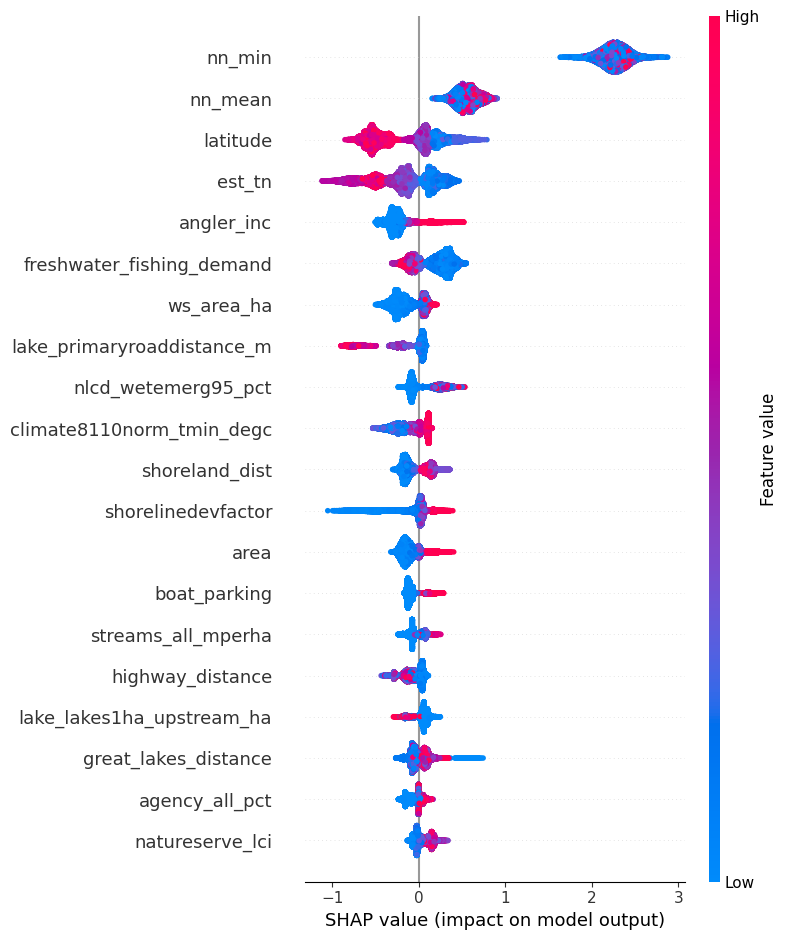

24113


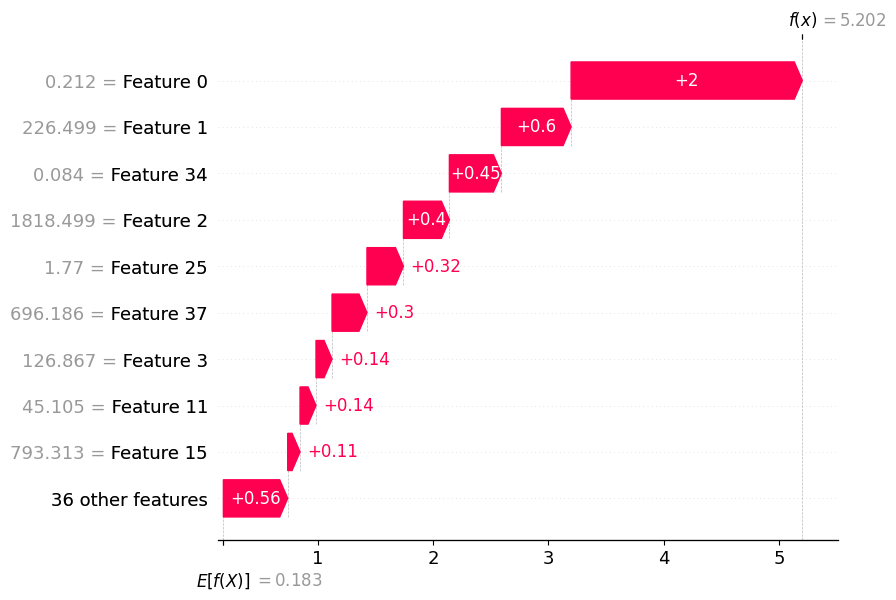

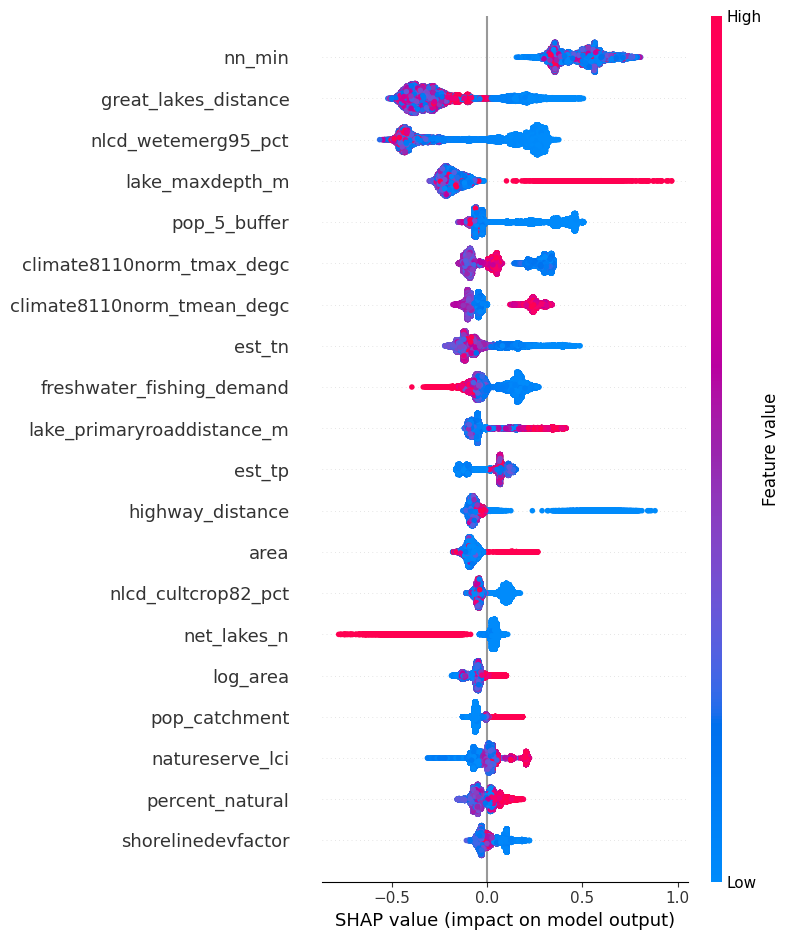

9078


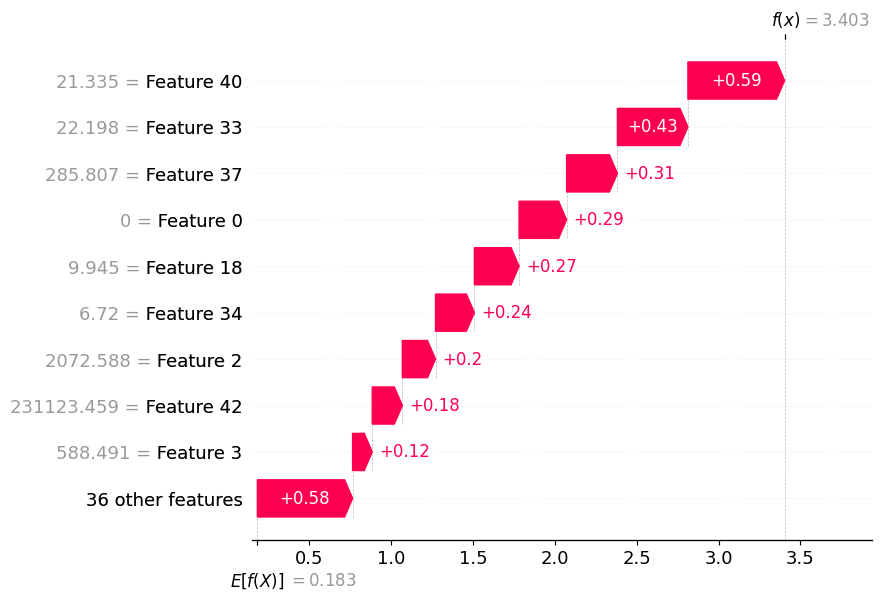

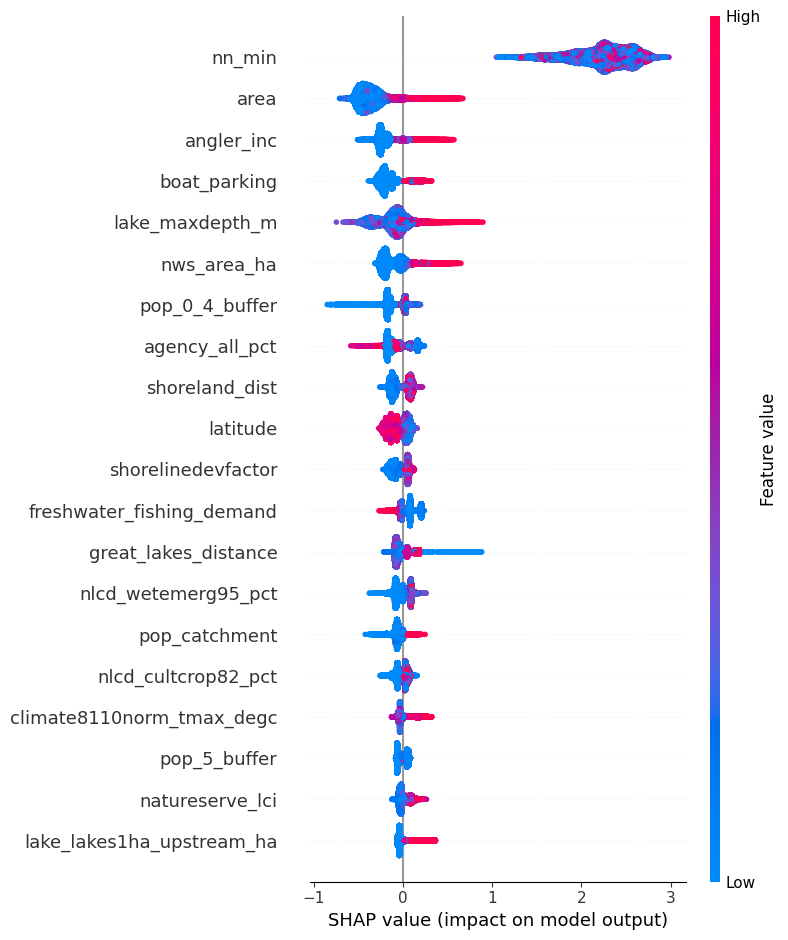

20103


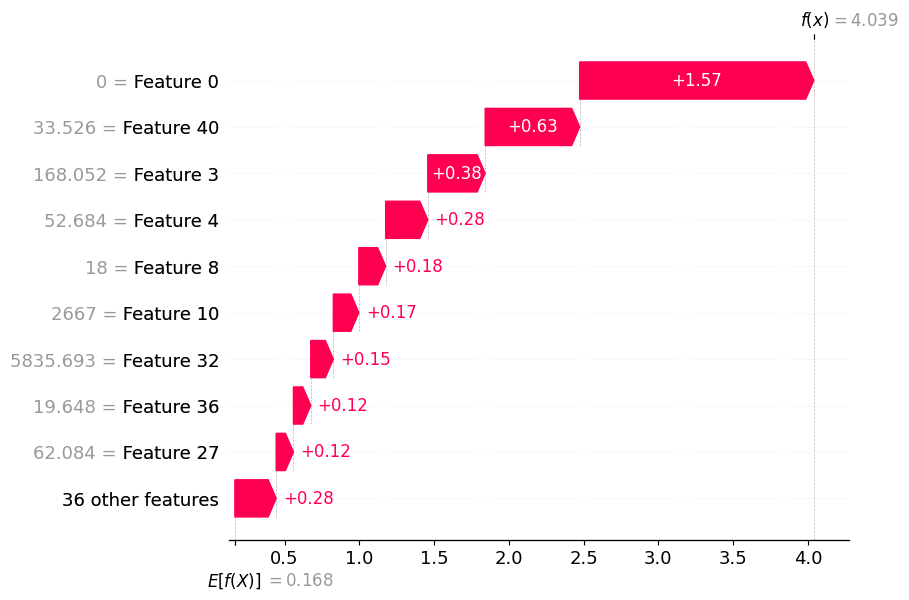

In [ ]:
import shap

for i, taxon in enumerate(['plant', 'fish', 'invert']):
  model = models_dct[taxon]

  # Create an explainer
  explainer = shap.TreeExplainer(model.best_estimator_)

  X_validation = Xfull_dct[taxon]
  #X_validation = testdata[:,4:]

  # Calculate SHAP values for the test set
  shap_values = explainer.shap_values(X_validation)

  # Plot SHAP summary plot
  shap.summary_plot(shap_values, X_validation, feature_names=indatas[i].columns[3:])

  exp = explainer(X_validation) # <-- here

  # get index of highest-prob lake
  idx = merged_df[taxon+"risk"].idxmax()
  print(idx)

  shap.plots.waterfall(exp[idx])



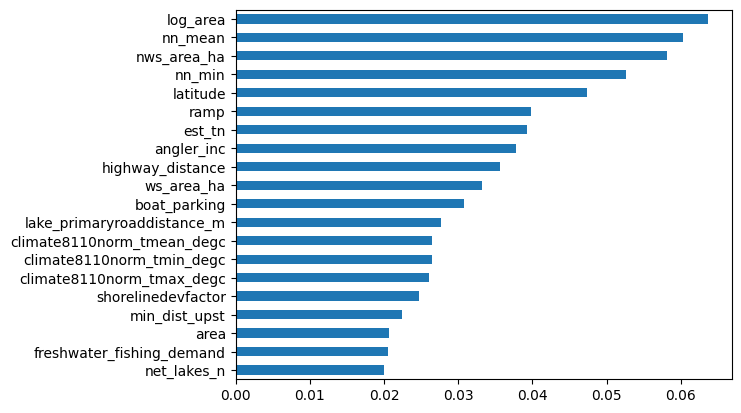

In [ ]:
#xgb.plot_importance(featimp_dct["plant"]).set_yticklabels(lakes_env.columns[1:])

feat_importances = pd.Series(featimp_dct["plant"][0], index=indatas[0].columns[3:])
feat_importances.nlargest(20).plot(kind='barh').invert_yaxis()

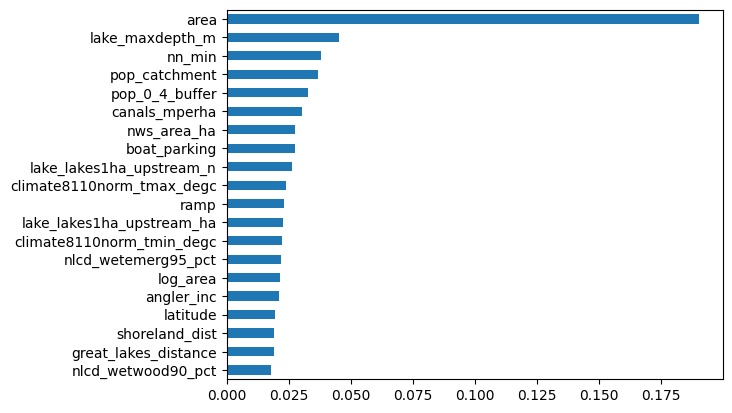

In [ ]:
feat_importances = pd.Series(featimp_dct["invert"][0], index=indatas[1].columns[3:])
feat_importances.nlargest(20).plot(kind='barh').invert_yaxis()

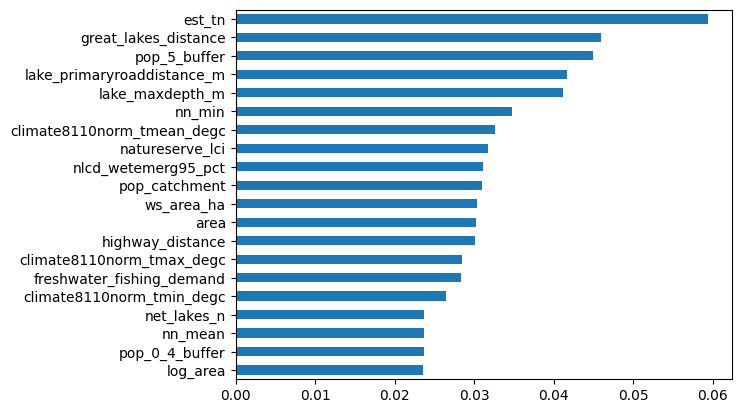

In [ ]:
feat_importances = pd.Series(featimp_dct["fish"][0], index=indatas[2].columns[3:])
feat_importances.nlargest(20).plot(kind='barh').invert_yaxis()

In [ ]:
# performance on the later data left out of the model training
for taxon in ['plant', 'fish', 'invert']:
  print(taxon)
  ilakes_2425 = len(testdata_dct[taxon][testdata_dct[taxon]['inv'] == 1])
  print('invaded lakes: ', ilakes_2425)
  outdata = testdata_dct[taxon]
  outdata = outdata.reset_index(drop=True)
  outdataset = outdata.values
  X_out = outdataset[:,3:]
  Y_out = outdataset[:,2]
  out_train = models_dct[taxon].predict(X_out)
  pred_p = models_dct[taxon].predict_proba(X_out)[::,1]
  print('Accuracy on 2024-25 data = {:.4f}'.format(
          accuracy_score(y_true=Y_out, y_pred=out_train),
      ))
  print('avg pred_p', pred_p.mean())



plant
invaded lakes:  97
Accuracy on 2024-25 data = 0.7515
avg pred_p 0.45344025
fish
invaded lakes:  12
Accuracy on 2024-25 data = 0.7692
avg pred_p 0.42458165
invert
invaded lakes:  171
Accuracy on 2024-25 data = 0.7659
avg pred_p 0.46351317


In [ ]:
feature_names = indata.columns[4:]
feature_names[1]

'area'

In [ ]:
lakes_env_imputed['lagoslakeid'][1386]

4024.0

In [ ]:
feature_names

Index(['freshwater_fishing_demand', 'area', 'angler_inc', 'highway_distance',
       'log_area', 'ramp', 'boat_parking', 'percent_natural', 'pop_catchment',
       'natureserve_lci', 'shorelinedevfactor', 'lake_lakes1ha_upstream_ha',
       'lake_lakes1ha_upstream_n', 'ws_area_ha', 'nws_area_ha',
       'streams_all_mperha', 'climate8110norm_tmax_degc',
       'climate8110norm_tmean_degc', 'climate8110norm_tmin_degc',
       'canals_mperha', 'nlcd_alldev_pct', 'nlcd_cultcrop82_pct',
       'nlcd_allwet_pct', 'nlcd_wetemerg95_pct', 'nlcd_wetwood90_pct',
       'shoreland_dist', 'lake_rsvr_probrsvr', 'lake_nets_damonlake_flag',
       'net_lakes_n', 'latitude', 'pop_0_4_buffer', 'pop_5_buffer',
       'great_lakes_distance', 'ramps_upstream', 'agency_all_pct', 'est_tn',
       'est_tp', 'est_chla', 'spp_upst', 'min_dist_upst', 'nn_dist_min',
       'nn_dist_mean'],
      dtype='object')

In [ ]:
idx = orig["invertrisk"].idxmax()
idx

14759

In [ ]:
orig['invertrisk'][1386]

In [ ]:
X_validation[1386,16:19]

array([ 9.69142151,  3.33532548, -3.02077127])

In [ ]:
import pickle

for taxon in ['plant', 'fish', 'invert']:
  model = models_dct[taxon]
  file_name = taxon+"_xgb_model.pkl"
  pickle.dump(model, open(file_name, "wb"))

# load
xgb_model_loaded = pickle.load(open(file_name, "rb"))

# test
ind = 1
test = X_validation[ind]
xgb_model_loaded.predict(test)[0] == xgb_model.predict(test)[0]

#Out[1]: True

XGBoostError: [03:14:44] /workspace/src/predictor/cpu_predictor.cc:789: Check failed: m->NumColumns() == model.learner_model_param->num_feature (1 vs. 42) : Number of columns in data must equal to trained model.
Stack trace:
  [bt] (0) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x25c1ac) [0x7de63645c1ac]
  [bt] (1) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x75d773) [0x7de63695d773]
  [bt] (2) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x75f53c) [0x7de63695f53c]
  [bt] (3) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x5aa1e8) [0x7de6367aa1e8]
  [bt] (4) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x5fde69) [0x7de6367fde69]
  [bt] (5) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x16a7ac) [0x7de63636a7ac]
  [bt] (6) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(XGBoosterPredictFromDense+0x10b) [0x7de63636acdb]
  [bt] (7) /lib/x8

In [ ]:
# prompt: zip together Y_out and out_train

import pandas as pd
# Assuming Y_out and out_train are defined in your existing code

# Zip Y_out and out_train
zipped_data = list(zip(Y_out, out_train))

# Convert to DataFrame for better handling (optional)
zipped_df = pd.DataFrame(zipped_data, columns=['Actual', 'Predicted'])

print(zipped_df.head(30))

    Actual  Predicted
0      0.0          0
1      0.0          0
2      0.0          0
3      0.0          0
4      0.0          0
5      0.0          0
6      0.0          0
7      0.0          0
8      0.0          0
9      0.0          0
10     1.0          1
11     1.0          1
12     0.0          0
13     1.0          1
14     1.0          1
15     1.0          1
16     1.0          1
17     0.0          0
18     0.0          0
19     0.0          0
20     0.0          0
21     0.0          0
22     0.0          0
23     1.0          1
24     0.0          0
25     0.0          0
26     0.0          0
27     0.0          0
28     0.0          0
29     0.0          0


In [ ]:
orig.columns

Index(['lagoslakeid', 'freshwater_fishing_demand', 'area', 'angler_inc',
       'highway_distance', 'log_area', 'ramp', 'boat_parking',
       'percent_natural', 'pop_catchment', 'natureserve_lci',
       'shorelinedevfactor', 'lake_lakes1ha_upstream_ha',
       'lake_lakes1ha_upstream_n', 'ws_area_ha', 'nws_area_ha',
       'streams_all_mperha', 'climate8110norm_tmax_degc',
       'climate8110norm_tmean_degc', 'climate8110norm_tmin_degc',
       'canals_mperha', 'nlcd_alldev_pct', 'nlcd_cultcrop82_pct',
       'nlcd_allwet_pct', 'nlcd_wetemerg95_pct', 'nlcd_wetwood90_pct',
       'shoreland_dist', 'lake_rsvr_probrsvr', 'lake_nets_damonlake_flag',
       'net_lakes_n', 'latitude', 'pop_0_4_buffer', 'pop_5_buffer',
       'great_lakes_distance', 'ramps_upstream', 'agency_all_pct', 'est_tn',
       'est_tp', 'est_chla', 'spp_upst', 'min_dist_upst', 'nn_dist_min',
       'nn_dist_mean', 'plantrisk', 'plant_pred', 'plant_adj_risk', 'fishrisk',
       'fish_pred', 'fish_adj_risk', 'plantr_p

Index(['lagoslakeid', 'freshwater_fishing_demand', 'area', 'angler_inc',
       'highway_distance', 'log_area', 'ramp', 'boat_parking',
       'percent_natural', 'pop_catchment', 'natureserve_lci',
       'shorelinedevfactor', 'lake_lakes1ha_upstream_ha',
       'lake_lakes1ha_upstream_n', 'ws_area_ha', 'nws_area_ha',
       'streams_all_mperha', 'climate8110norm_tmax_degc',
       'climate8110norm_tmean_degc', 'climate8110norm_tmin_degc',
       'canals_mperha', 'nlcd_alldev_pct', 'nlcd_cultcrop82_pct',
       'nlcd_allwet_pct', 'nlcd_wetemerg95_pct', 'nlcd_wetwood90_pct',
       'shoreland_dist', 'lake_rsvr_probrsvr', 'lake_nets_damonlake_flag',
       'net_lakes_n', 'latitude', 'pop_0_4_buffer', 'pop_5_buffer',
       'great_lakes_distance', 'ramps_upstream', 'agency_all_pct', 'est_tn',
       'est_tp', 'est_chla', 'buff100_publiclands_pct',
       'lake_primaryroaddistance_m', 'z', 'spp_upst', 'min_dist_upst',
       'nn_dist_min', 'nn_dist_mean', 'plantrisk', 'plant_pred',
       

/tmp/ipython-input-3920942832.py:43: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0,1].scatter(orig['plantrisk'], orig['fishr_norm'], cmap = cm.jet)
/tmp/ipython-input-3920942832.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1,0].scatter(orig['invertr_norm'], orig['fishr_norm'], cmap = cm.jet)


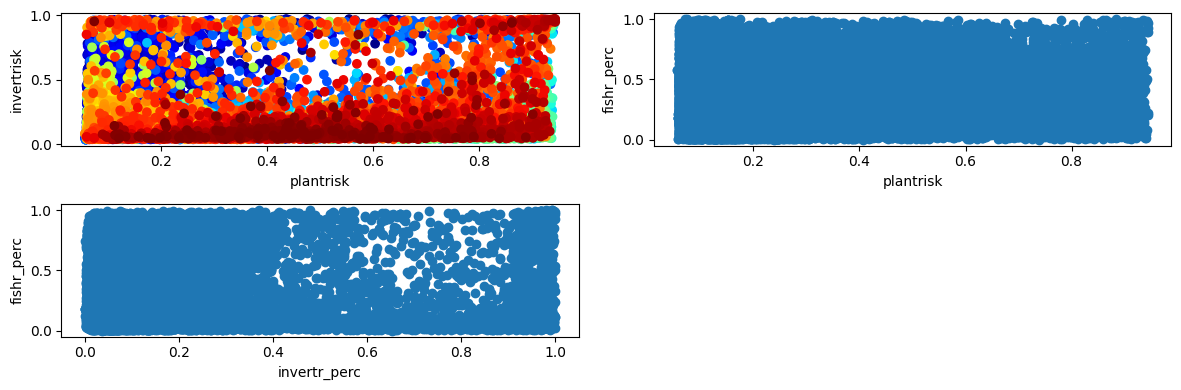

In [ ]:
# compare risk scores across taxa
# Create subplots
from scipy.stats import gaussian_kde

orig = pd.read_csv('risksout_upd_feb2026.csv')
print(orig.columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 4))


size = len(orig.plantrisk)-1
orig['plantr_perc'] = orig['plantrisk'].rank(pct=True)
orig['plantr_norm'] = (orig['plantrisk'] - min(orig['plantrisk']))/(max(orig['plantrisk'] - min(orig['plantrisk'])))
orig['invertr_perc'] = orig['invertrisk'].rank(pct=True)
orig['invertr_norm'] = (orig['invertrisk'] - min(orig['invertrisk']))/(max(orig['invertrisk'] - min(orig['invertrisk'])))
orig['fishr_perc'] = orig.fishrisk.rank(method='min').apply(lambda x: (x-1)/size)
orig['fishr_norm'] = (orig['fishrisk'] - min(orig['fishrisk']))/(max(orig['fishrisk'] - min(orig['fishrisk'])))

print(orig['plantrisk'].corr(orig['invertrisk']))
print(orig['fishrisk'].corr(orig['invertrisk']))
print(orig['plantrisk'].corr(orig['fishrisk']))

print(orig['plantrisk'].mean())
print(orig['invertrisk'].mean())
print(orig['fishrisk'].mean())
#mins_maxs = risk.groupby('lake_mapstate')['plantr_perc'].agg(['min','max']).reset_index()
#risk = risk.merge(mins_maxs,on='lake_mapstate')
#risk.plantr_perc =(risk['plantr_perc'] - risk['min']) / (risk['max']-risk['min']) #rescale back to 0 to 1
#risk = risk.drop(columns=['min', 'max'])
import matplotlib.cm as cm

# Plot scatterplots
# Calculate the point density
plantrisk = orig['plantrisk']
invertrisk = orig['invertrisk']
xy = np.vstack([plantrisk,invertrisk])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
plantrisk, invertrisk, z = plantrisk[idx], invertrisk[idx], z[idx]
axes[0,0].scatter(orig['plantrisk'], orig['invertrisk'], c=z, cmap = cm.jet)
axes[0,0].set_xlabel('plantrisk')
axes[0,0].set_ylabel('invertrisk')

axes[0,1].scatter(orig['plantrisk'], orig['fishr_norm'], cmap = cm.jet)
axes[0,1].set_xlabel('plantrisk')
axes[0,1].set_ylabel('fishr_perc')

axes[1,0].scatter(orig['invertr_norm'], orig['fishr_norm'], cmap = cm.jet)
axes[1,0].set_xlabel('invertr_perc')
axes[1,0].set_ylabel('fishr_perc')

fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

In [ ]:
# Create the boxplot
plt.boxplot(data)

# Add title and labels
plt.title('Boxplot Example')
plt.ylabel('Values')

# Show the plot
plt.show()

In [ ]:
pred_p = xgb_grid_model.predict_proba(Xfull)

In [ ]:
pred_p

array([[0.00166363, 0.9983364 ],
       [0.00306189, 0.9969381 ],
       [0.0019542 , 0.9980458 ],
       ...,
       [0.04832047, 0.9516795 ],
       [0.02854896, 0.97145104],
       [0.13649452, 0.8635055 ]], dtype=float32)

In [ ]:
print(bg_comb)

      lagoslakeid  year  fold  inv  Unnamed: 0  freshwater_fishing_demand  \
0         20571.0  1975     0    1       15427                8375.535618   
1         48184.0  1977     0    1       12422               18754.058455   
2          7326.0  1977     0    1       12420                6865.188175   
3         46117.0  1977     0    1       12390               19519.846573   
4         29301.0  1977     0    1       12231               17687.981125   
...           ...   ...   ...  ...         ...                        ...   
1282      49176.0  2024     4    1       24648                6039.326538   
1283      50036.0  2023     4    1       16670                2727.587966   
1284      50429.0  2024     4    1        3775                1459.307157   
1285      51285.0  2023     4    1       24181                6834.032204   
1286      52284.0  2023     4    1       23133              102146.714401   

            area  angler_inc  highway_distance  log_area  ...  ramps_upstre

In [ ]:
inv_comb.columns[4:]

Index(['freshwater_fishing_demand', 'area', 'angler_inc', 'highway_distance',
       'log_area', 'ramp', 'boat_parking', 'percent_natural', 'pop_catchment',
       'natureserve_lci', 'shorelinedevfactor', 'lake_lakes1ha_upstream_ha',
       'lake_lakes1ha_upstream_n', 'ws_area_ha', 'nws_area_ha',
       'streams_all_mperha', 'climate8110norm_tmax_degc',
       'climate8110norm_tmean_degc', 'climate8110norm_tmin_degc',
       'canals_mperha', 'nlcd_alldev_pct', 'nlcd_cultcrop82_pct',
       'nlcd_allwet_pct', 'nlcd_wetemerg95_pct', 'nlcd_wetwood90_pct',
       'shoreland_dist', 'lake_rsvr_probrsvr', 'lake_nets_damonlake_flag',
       'net_lakes_n', 'latitude', 'pop_0_4_buffer', 'pop_5_buffer',
       'great_lakes_distance', 'ramps_upstream', 'agency_all_pct', 'est_tn',
       'est_tp', 'est_chla', 'spp_upst_x', 'min_dist_upst_x', 'nn_dist_min_x',
       'nn_dist_mean_x', 'Permanent_', 'spp_upst_y', 'min_dist_upst_y',
       'nn_dist_min_y', 'nn_dist_mean_y'],
      dtype='object')

In [ ]:
indata.columns[3]

'inv'

In [ ]:
indata.columns

Index(['lagoslakeid', 'year', 'fold', 'inv', 'freshwater_fishing_demand',
       'area', 'angler_inc', 'highway_distance', 'log_area', 'ramp',
       'boat_parking', 'percent_natural', 'pop_catchment', 'natureserve_lci',
       'shorelinedevfactor', 'lake_lakes1ha_upstream_ha',
       'lake_lakes1ha_upstream_n', 'ws_area_ha', 'nws_area_ha',
       'streams_all_mperha', 'climate8110norm_tmax_degc',
       'climate8110norm_tmean_degc', 'climate8110norm_tmin_degc',
       'canals_mperha', 'nlcd_alldev_pct', 'nlcd_cultcrop82_pct',
       'nlcd_allwet_pct', 'nlcd_wetemerg95_pct', 'nlcd_wetwood90_pct',
       'shoreland_dist', 'lake_rsvr_probrsvr', 'lake_nets_damonlake_flag',
       'net_lakes_n', 'nn_mean', 'nn_min', 'latitude', 'pop_0_4_buffer',
       'pop_5_buffer', 'great_lakes_distance', 'ramps_upstream',
       'agency_all_pct', 'est_tn', 'est_tp', 'est_chla', 'lake_maxdepth_m',
       'buff100_publiclands_pct', 'lake_primaryroaddistance_m', 'spp_upst',
       'min_dist_upst', 'nn_dis

In [ ]:
xgb.plot_importance(grid.best_estimator_).set_yticklabels(orig_feature_names)

NameError: name 'grid' is not defined

In [ ]:
orig

,lagoslakeid,lake_nhdid,FFD,AREA,ANGLER_INC,HWY_DIST,LOG_AREA,RAMP,BOAT_PKG,PCT_NAT,...,Shape_Length,Shape_Area,GL_DIST,ramps_upstream,lagoslakeid_1,upst_spp,lake_mapstate,plantrisk,fishrisk,invertrisk
0,105826,122243215,51963.466064,3.298674,0.0,0.955016,0.518339,0,0,0.335025,...,1467.934357,32986.735784,336.399071,0,105826,0,NaN,0.184450,0.928127,0.758728
1,16324,122231830,51963.466064,1.793905,0.0,0.862549,0.253799,0,0,0.835165,...,519.037627,17939.051198,336.355606,0,16324,0,NaN,0.547352,0.963413,0.947097
2,15308,122231812,58255.986908,3.294539,0.0,1.552322,0.517795,0,0,0.721649,...,879.573622,32945.391157,337.304180,0,15308,0,NaN,0.465143,0.976901,0.945702
3,117141,b079d9cd-efed-48c7-9dc9-0281a1cc180a,49944.644180,3.062337,0.0,22.400530,0.486053,0,0,0.296813,...,935.458150,30623.365337,288.311750,0,117141,0,NaN,0.704512,0.997914,0.907197
4,121396,122231751,58255.986908,1.261849,0.0,2.814665,0.101007,0,0,1.000000,...,541.716954,12618.490793,335.679172,0,121396,0,NaN,0.692028,0.987287,0.951156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111725,110761,132542690,2629.603305,2.304008,0.0,11.939562,0.362484,0,0,0.424779,...,559.179137,23040.084006,419.309002,0,110761,0,NaN,NaN,NaN,NaN
111726,30894,132542623,2629.603305,25.982028,0.0,10.942510,1.414673,0,0,0.445910,...,1997.101165,259820.283208,417.668731,0,30894,0,NaN,NaN,NaN,NaN
111727,134377,80997595,458.766516,14.519548,0.0,163.177934,1.161953,0,0,0.465930,...,2074.670133,145195.483366,35.288468,0,134377,0,NaN,NaN,NaN,NaN
111728,140516,80997397,458.766516,22.225001,0.0,163.581689,1.346842,0,0,0.659449,...,2846.435229,222250.013405,35.731580,0,140516,0,NaN,NaN,NaN,NaN


In [ ]:
fpr , tpr, thresholds = roc_curve(y_test, y_pred_prob)
# plot the computed values
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr, tpr, label= '%s ROC (area = %0.2f)' % (taxon, roc_auc))
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.show()

# get predictions for all lakes
pred_p = grid.predict_proba(Xfull)
df = pd.DataFrame(pred_p)

orig = orig.join(df)
orig = orig.drop(columns=[0])
orig = orig.rename(columns={1: taxon+"risk"})
#orig.head()
elapsed = time.time() - program_time
print("time: ", elapsed/60, " min")

NameError: name 'y_test' is not defined

In [ ]:
taxon="plant"
fpr , tpr, thresholds = roc_curve(y_test, y_pred_prob)
# plot the computed values
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr, tpr, label= '%s ROC (area = %0.2f)' % (taxon, roc_auc))
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.show()

In [ ]:
indata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Y                           300 non-null    int64  
 1   FFD                         266 non-null    float64
 2   ANGLER_INC                  300 non-null    float64
 3   HWY_DIST                    300 non-null    float64
 4   LOG_AREA                    300 non-null    float64
 5   RAMP                        300 non-null    int64  
 6   BOAT_PKG                    300 non-null    int64  
 7   PCT_NAT                     300 non-null    float64
 8   POP_CATCH                   300 non-null    float64
 9   natserv                     300 non-null    float64
 10  lake_shorelinedevfactor     300 non-null    float64
 11  lake_lakes1ha_upstream_ha   300 non-null    float64
 12  lake_lakes1ha_upstream_n    300 non-null    float64
 13  ws_area_ha                  300 non

In [ ]:
orig

,lagoslakeid,freshwater_fishing_demand,area,angler_inc,highway_distance,log_area,ramp,boat_parking,percent_natural,pop_catchment,natureserve_lci,shorelinedevfactor,lake_lakes1ha_upstream_ha,lake_lakes1ha_upstream_n,ws_area_ha,nws_area_ha,streams_all_mperha,climate8110norm_tmax_degc,climate8110norm_tmean_degc,climate8110norm_tmin_degc,canals_mperha,nlcd_alldev_pct,nlcd_cultcrop82_pct,nlcd_allwet_pct,nlcd_wetemerg95_pct,nlcd_wetwood90_pct,shoreland_dist,lake_rsvr_probrsvr,lake_nets_damonlake_flag,net_lakes_n,latitude,pop_0_4_buffer,pop_5_buffer,great_lakes_distance,ramps_upstream,agency_all_pct,est_tn,est_tp,est_chla,buff100_publiclands_pct,lake_primaryroaddistance_m,z,spp_upst,min_dist_upst,nn_dist_min,nn_dist_mean,plantrisk,plant_pred,plant_adj_risk,fishrisk,fish_pred,fish_adj_risk,invertrisk,invert_pred,invert_adj_risk,plantr_perc,plantr_norm,invertr_perc,invertr_norm,fishr_perc,fishr_norm
0,50697.0,2913.746613,957.902162,3.472268,18.710602,2.981321,1.0,5.0,0.441566,0.0,56.079139,3.555096,8820.595969,157.0,14638.900000,283205.300000,4.043107,12.185081,6.205914,0.226747,0.003310,3.360295,72.118099,17.290481,17.016146,0.274335,4.244919,0.7164,0.0,754.0,45.788803,6.108748,207.091575,350.489299,1.0,6.422826,2413.893682,229.765714,45.876145,54.159,18698.063,7.601592,0.0,1000.000,62148.176066,564156.385264,0.111876,0,0.273601,0.182786,0,0.426267,0.261998,0,0.435507,0.319562,0.062154,0.817178,0.243550,0.371210,0.181919
1,666.0,1590.217193,4349.351348,12.710346,10.201618,3.638424,1.0,14.0,0.546679,102.0,42.626735,3.026932,4428.644621,153.0,166103.200000,259357.100000,8.543020,12.230717,6.288421,0.346125,3.590677,3.952843,88.877878,3.994889,3.901423,0.093466,30.278722,1.0000,1.0,754.0,45.704452,114.188095,803.819316,356.393236,1.0,4.468950,1798.314353,139.003790,34.067464,13.318,10173.034,20.290227,10.0,57.164,61001.478401,567641.560716,0.082706,0,0.250271,0.183375,0,0.426947,0.060144,0,0.172797,0.191290,0.029258,0.175864,0.028422,0.372135,0.182515
2,21389.0,2840.356257,39.674873,0.092333,24.254710,1.598516,0.0,0.0,0.323634,0.0,24.165605,1.228698,0.000000,0.0,85.885130,85.885130,0.000000,11.782664,5.991142,0.199619,0.000000,4.732510,88.477366,0.823045,0.823045,0.000000,87.096774,0.0431,0.0,0.0,45.884663,3.413369,101.916133,312.211321,0.0,0.000000,1303.334939,65.135856,22.294932,0.000,24258.648,2.677991,0.0,1000.000,36634.805846,528368.025447,0.159574,0,0.314534,0.150908,0,0.389997,0.070939,0,0.183014,0.447348,0.115944,0.262482,0.039928,0.325855,0.149618
3,16107.0,2840.356257,24.560656,0.000000,26.323057,1.390240,0.0,0.0,0.398190,1.0,20.310811,1.239983,0.000000,0.0,35.189350,35.189350,0.000000,11.796742,6.000797,0.204851,0.000000,11.450382,81.679389,3.307888,3.307888,0.000000,80.286738,0.1099,0.0,0.0,45.875867,8.569496,86.788656,314.236619,0.0,0.000000,1294.974075,63.514335,21.660194,0.000,26327.235,3.580683,0.0,1000.000,36669.766316,529937.702271,0.172686,0,0.326351,0.150855,0,0.389937,0.129016,0,0.245983,0.472555,0.130731,0.549830,0.101823,0.325758,0.149564
4,50700.0,2840.356257,37.459121,0.430706,27.541233,1.573558,1.0,8.0,0.232448,4.0,31.122363,2.489001,1786.649841,65.0,13306.770000,39300.610000,9.675289,11.814341,6.010695,0.207048,2.127052,3.313202,81.384119,9.173356,9.096934,0.076422,41.362126,1.0000,1.0,754.0,45.874671,7.949963,88.482732,315.394153,1.0,8.545753,2351.417915,195.288043,44.898619,0.000,27545.492,3.211691,10.0,22.330,36681.057903,530846.762281,0.113305,0,0.274778,0.101612,0,0.336341,0.124564,0,0.240678,0.324234,0.063766,0.533674,0.097078,0.236508,0.099670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20545,12594.0,3420.058015,165.416055,0.856471,85.992447,2.218578,1.0,30.0,0.855568,18.0,82.183951,2.717284,0.000000,0.0,524.578292,524.578292,1.492840,11.578707,5.517127,-0.544454,0.000000,5.720158,0.000000,8.614489,0.068

In [ ]:
risk

,lagoslakeid,freshwater_fishing_demand,area,angler_inc,highway_distance,log_area,ramp,boat_parking,percent_natural,pop_catchment,...,nn_dist_mean_fish,fishrisk,fish_pred,fish_adj_risk,nn_dist_min_invert,nn_dist_mean_invert,invertrisk,invert_pred,invert_adj_risk,lake_mapst
0,34183.0,2134.251778,8.112577,0.0,53.686859,0.909159,0.0,0.0,0.667199,0.0,...,194.688381,0.413582,0,0.791228,4.037119,107.275219,0.230059,0,0.391686,NY
1,86269.0,62089.935181,3.332363,1.0,10.849577,0.522752,0.0,0.0,0.837963,11.0,...,212.476140,0.413582,0,0.791228,8.359977,65.559586,0.184935,0,0.292038,NY
2,21668.0,4141.168058,3.255663,0.0,6.005683,0.512639,0.0,0.0,0.155832,10.0,...,197.266429,0.413582,0,0.791228,20.829666,79.687021,0.214275,0,0.355263,NY
3,42727.0,4141.168058,4.449349,0.0,7.485048,0.648296,0.0,0.0,0.246944,0.0,...,196.694837,0.413582,0,0.791228,19.337886,79.194474,0.214275,0,0.355263,NY
4,106840.0,7251.678993,6.271723,0.0,15.449810,0.797387,0.0,0.0,0.676316,12.0,...,190.823955,0.413582,0,0.791228,2.952989,80.078777,0.299403,0,0.560712,NY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68704,44652.0,2108.578193,82.137173,0.0,12.038222,1.914540,0.0,0.0,0.118295,1.0,...,637.555259,0.413582,0,0.791228,79.841726,523.363785,0.192843,0,0.308429,MN
68705,9572.0,4043.552190,3.458002,0.0,0.016217,0.538825,0.0,0.0,0.048352,0.0,...,632.835354,0.413582,0,0.791228,69.793686,517.666496,0.208767,0,0.342915,MN
68706,11066.0,2998.344297,9.596444,0.0,12.235042,0.982110,0.0,0.0,0.051071,0.0,...,631.074621,0.413582,0,0.791228,84.771131,517.834862,0.215469,0,0.357968,MN
68707,110761.0,2629.603305,2.304008,0.0,11.939562,0.362484,0.0,0.0,0.424779,0.0,...,626.236101,0.413582,0,0.791228,88.464531,513.582685,0.223424,0,0.376202,MN


In [ ]:
risk['fish_adj_risk'].min()

0.7912282347679138

In [ ]:
risk.to_csv('risksout_upd_feb2026_states.csv', index=False)

In [ ]:
# normalize for web app to give each state a reasonable distribution of higher and lower priority lakes because MN is so weird

for column in risk[['plantrisk', 'fishrisk', 'invertrisk']]:

    # Select column contents by column
    # name using [] operator
    columnSeriesObj = risk[column]

    #calculate z-scores
    means_stds = risk.groupby('lake_mapst')[column].agg(['mean','std']).reset_index()
    risk = risk.merge(means_stds,on='lake_mapst')
    risk[column+'z'] = (risk[column] - risk['mean']) / (risk['std'])

    # deal with outliers
    z_thresh = 3 # outlier threshold 3 stds
    risk['outliers_z'] = np.abs(risk[column+'z']) > z_thresh
    risk['rt_mean'] = risk[risk['outliers_z'] == False][column].mean() # mean of non-outliers
    risk.loc[risk[column+'z'] < -3, column] = risk['mean'] - 3*risk['std'] # replace with most extreme value not considered an outlier
    risk.loc[risk[column+'z'] > 3, column] = risk['mean'] + 3*risk['std']
    risk = risk.drop(columns=['mean', 'std', 'outliers_z', 'rt_mean'])

    # rescale
    mins_maxs = risk.groupby('lake_mapst')[column+'z'].agg(['min','max']).reset_index()
    risk = risk.merge(mins_maxs,on='lake_mapst')
    risk[column+'z'] =(risk[column+'z'] - risk['min']) / (risk['max']-risk['min']) #rescale back to 0 to 1
    risk = risk.drop(columns=['min', 'max'])

    #from scipy import stats
    #risk['plantrnorm'] = stats.zscore(risk['plantrisk'])

    #df[col_zscore] = (df[col] - df[col].mean())/df[col].std(ddof=0)
    risk[column+'z'].describe()

In [ ]:
# loop through ex
for col in df.columns:
        if df[col].dtypes == "float":
           df[ col&'_change'] = (df.col - df.groupby(['New_ID']).col.shift(1))/ df.col

AttributeError: 'DataFrame' object has no attribute 'col'

In [ ]:
orig[orig['lagoslakeid'] == 46374]

,lagoslakeid,freshwater_fishing_demand,area,angler_inc,highway_distance,log_area,ramp,boat_parking,percent_natural,pop_catchment,natureserve_lci,shorelinedevfactor,lake_lakes1ha_upstream_ha,lake_lakes1ha_upstream_n,ws_area_ha,nws_area_ha,streams_all_mperha,climate8110norm_tmax_degc,climate8110norm_tmean_degc,climate8110norm_tmin_degc,canals_mperha,nlcd_alldev_pct,nlcd_cultcrop82_pct,nlcd_allwet_pct,nlcd_wetemerg95_pct,nlcd_wetwood90_pct,shoreland_dist,lake_rsvr_probrsvr,lake_nets_damonlake_flag,net_lakes_n,latitude,pop_0_4_buffer,pop_5_buffer,great_lakes_distance,ramps_upstream,agency_all_pct,est_tn,est_tp,est_chla,buff100_publiclands_pct,lake_primaryroaddistance_m,z,spp_upst,min_dist_upst,nn_dist_min,nn_dist_mean,plantrisk,plant_pred,plant_adj_risk,fishrisk,fish_pred,fish_adj_risk,invertrisk,invert_pred,invert_adj_risk,plantr_perc,plantr_norm,invertr_perc,invertr_norm,fishr_perc,fishr_norm
7362,46374.0,19023.196838,2.711874,0.849096,4.700881,0.43327,0.0,0.0,0.74,0.0,34.83871,1.182918,0.0,0.0,108.2371,108.2371,9.02906,12.126802,6.297214,0.467625,0.0,5.985037,18.786367,0.0,0.0,0.0,46.788991,1.0,1.0,32811.0,45.216929,9.350785,622.122995,161.628487,0.0,0.0,1126.791607,37.227415,16.789707,0.0,4663.455,3.799051,0.0,1000.0,42530.625277,340197.431374,0.263435,0,0.413595,0.087313,0,0.321469,0.049911,0,0.163534,0.574258,0.23307,0.085985,0.017517,0.205752,0.085181


Colab uses execution history to save all the previous operations that ran in the notebook. you can access it by clicking on the “View” menu and then “Executed code history”. This opens a side panel showing all the cells we have executed so far in order. Each entry includes the cell source and output generated.

In [ ]:
risk = risk.drop(columns=['mean_x','mean_y','std_x','std_y'])

KeyError: "['mean_x', 'mean_y', 'std_x', 'std_y'] not found in axis"

In [ ]:
# normalize by state because MN is so weird
#risknorm = risk.groupby('lake_mapstate').transform(lambda x: (x - x.mean()) / x.std())
means_stds = risk.groupby('lake_mapst')['plantrisk'].agg(['mean','std']).reset_index()
risk = risk.merge(means_stds,on='lake_mapst')
risk['plantz'] = (risk['plantrisk'] - risk['mean']) / (risk['std'])
risk = risk.drop(columns=['mean', 'std'])
#from scipy import stats
#risk['plantrnorm'] = stats.zscore(risk['plantrisk'])

#df[col_zscore] = (df[col] - df[col].mean())/df[col].std(ddof=0)
risk.plantz.describe()

,plantz
count,2.055000e+04
mean,-4.978986e-17
std,9.998297e-01
min,-3.032933e+00
25%,-7.115484e-01
50%,-2.405684e-01
75%,5.871410e-01
max,3.610260e+00


In [ ]:
risk.plantz[risk.plantz > 3.0].count()

0

In [ ]:
risk.plantz[risk.plantz < -3.0].count()

924

In [ ]:
#risk.plantrisk[risk.plantz < -3.0] = risk['mean'] - 3*risk['std'] # deal with outliers
means_stds = risk.groupby('lake_mapst')['plantrisk'].agg(['mean','std']).reset_index()
risk = risk.merge(means_stds,on='lake_mapst')
risk.loc[risk['plantz'] < -3, 'plantrisk'] = risk['mean'] - 3*risk['std']
risk = risk.drop(columns=['mean', 'std'])


In [ ]:
mins_maxs = risk.groupby('lake_mapst')['plantz'].agg(['min','max']).reset_index()
risk = risk.merge(mins_maxs,on='lake_mapst')
risk.plantz =(risk['plantz'] - risk['min']) / (risk['max']-risk['min']) #rescale back to 0 to 1
risk = risk.drop(columns=['min', 'max'])

In [ ]:
def normalize(column):
    upper = column.max()
    lower = column.min()
    y = (column - lower)/(upper-lower)
    return y
risk['plantrnorm'] = stats.zscore(risk['plantrisk'])
risk.plantrnorm = np.log(risk.plantrnorm + 1)
mins_maxs = risk.groupby('lake_mapst')['plantrnorm'].agg(['min','max']).reset_index()
risk = risk.merge(mins_maxs,on='lake_mapst')
risk.plantrnorm =(risk['plantrnorm'] - risk['min']) / (risk['max']-risk['min'])
risk = risk.drop(columns=['min', 'max'])

NameError: name 'stats' is not defined

In [ ]:
# convert to percentiles
size = len(risk.plantrisk)-1
risk['plantr_perc'] = risk.groupby('lake_mapst').plantrisk.rank(method='min').apply(lambda x: (x-1)/size)
#mins_maxs = risk.groupby('lake_mapstate')['plantr_perc'].agg(['min','max']).reset_index()
#risk = risk.merge(mins_maxs,on='lake_mapstate')
#risk.plantr_perc =(risk['plantr_perc'] - risk['min']) / (risk['max']-risk['min']) #rescale back to 0 to 1
#risk = risk.drop(columns=['min', 'max'])
risk.plantr_perc.describe()

,plantr_perc
count,20550.000000
mean,0.095941
std,0.080521
min,0.000000
25%,0.031145
50%,0.071780
75%,0.145555
max,0.313884


In [ ]:
risk.head()

,lagoslakeid,lake_nhdid,FFD,AREA,ANGLER_INC,HWY_DIST,LOG_AREA,RAMP,BOAT_PKG,PCT_NAT,...,upst_spp,fishrisk,plantrisk,invertrisk,lake_mapstate,plantrnorm,min_x,max_x,min_y,max_y
0,105826,122243215,51963.46606,3.298674,0.0,0.955016,0.518339,0,0,0.335025,...,0,0.928127,0.184450,0.758728,NY,0.207026,0.014834,0.686289,0.0,0.693147
1,16324,122231830,51963.46606,1.793905,0.0,0.862549,0.253799,0,0,0.835165,...,0,0.963413,0.547352,0.947097,NY,0.487386,0.014834,0.686289,0.0,0.693147
2,15308,122231812,58255.98691,3.294539,0.0,1.552322,0.517795,0,0,0.721649,...,0,0.976901,0.465143,0.945702,NY,0.436157,0.014834,0.686289,0.0,0.693147
3,117141,b079d9cd-efed-48c7-9dc9-0281a1cc180a,49944.64418,3.062337,0.0,22.400530,0.486053,0,0,0.296813,...,0,0.997915,0.704512,0.907197,NY,0.572178,0.014834,0.686289,0.0,0.693147
4,121396,122231751,58255.98691,1.261849,0.0,2.814665,0.101007,0,0,1.000000,...,0,0.987287,0.692028,0.951156,NY,0.565980,0.014834,0.686289,0.0,0.693147


array([[<Axes: title={'center': 'IL'}>, <Axes: title={'center': 'IN'}>,
        <Axes: title={'center': 'MI'}>],
       [<Axes: title={'center': 'MN'}>, <Axes: title={'center': 'NY'}>,
        <Axes: title={'center': 'OH'}>],
       [<Axes: title={'center': 'PA'}>, <Axes: title={'center': 'WI'}>,
        <Axes: >]], dtype=object)

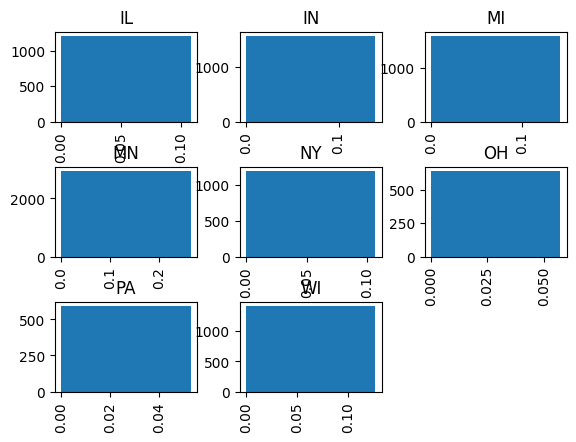

In [ ]:
risk.hist('plantr_perc', by='lake_mapstate')

In [ ]:
D_train = xgb.DMatrix(X_train, label=y_train)
D_test = xgb.DMatrix(X_test, label=y_test)

param = {
    'learning_rate': 0.1,
    'max_depth': 5,
    'min_child_weight': 1,
    'gamma': 0,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'binary:logistic',
    'nthread': 4,
    'scale_pos_weight': 1,}

steps = 20  # The number of training iterations

In [ ]:
# fit model on training data
#model = xgb.XGBClassifier()
#model.fit(X_train, y_train)
model = xgb.train(param, D_train, steps)



AttributeError: 'numpy.ndarray' object has no attribute 'info'

In [ ]:
pred_p = grid.predict_proba(X_test)

In [ ]:
preds

array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1])

In [ ]:
pred_p

array([[4.1506290e-03, 9.9584937e-01],
       [1.1509299e-02, 9.8849070e-01],
       [9.9768203e-01, 2.3179718e-03],
       [3.0301213e-03, 9.9696988e-01],
       [9.9030936e-01, 9.6906321e-03],
       [7.3963404e-04, 9.9926037e-01],
       [1.1509299e-02, 9.8849070e-01],
       [9.9791622e-01, 2.0837877e-03],
       [9.9449891e-01, 5.5010896e-03],
       [1.4341587e-01, 8.5658413e-01],
       [9.8394465e-01, 1.6055347e-02],
       [9.1397762e-03, 9.9086022e-01],
       [1.9938409e-02, 9.8006159e-01],
       [1.3515174e-02, 9.8648483e-01],
       [9.9063689e-01, 9.3631055e-03],
       [9.7347498e-03, 9.9026525e-01],
       [9.9823779e-01, 1.7621958e-03],
       [6.9317937e-01, 3.0682063e-01],
       [1.7810225e-02, 9.8218977e-01],
       [9.9742889e-01, 2.5711127e-03],
       [1.3933134e-01, 8.6066866e-01],
       [9.3945444e-02, 9.0605456e-01],
       [9.8528945e-01, 1.4710550e-02],
       [9.8949081e-01, 1.0509173e-02],
       [9.9414086e-01, 5.8591245e-03],
       [1.5201867e-02, 9.

In [ ]:
grid.best_params_

{'colsample_bytree': 0.7,
 'eta': 0.2,
 'gamma': 0.0,
 'max_depth': 8,
 'min_child_weight': 1}

In [ ]:
model.dump_model('plants_dump.raw.txt')


In [ ]:
from sklearn.metrics import roc_auc_score
eval_auc = roc_auc_score( y_test, grid.best_estimator_.predict_proba(X_test)[:,1])


In [ ]:
eval_auc

0.9675925925925927

In [ ]:
fishgrid = grid

In [ ]:
plantgrid.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.05, eval_metric=None,
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=12,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
invertgrid.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.05, eval_metric=None,
              feature_types=None, gamma=0.0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=15,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# load data
sampdata = pd.read_csv('iris.txt', header=None)
dataset = sampdata.values

In [ ]:
sampdata.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
dataset

array([[5.1, 3.5, 1.4, 0.2, 'Iris-setosa'],
       [4.9, 3.0, 1.4, 0.2, 'Iris-setosa'],
       [4.7, 3.2, 1.3, 0.2, 'Iris-setosa'],
       [4.6, 3.1, 1.5, 0.2, 'Iris-setosa'],
       [5.0, 3.6, 1.4, 0.2, 'Iris-setosa'],
       [5.4, 3.9, 1.7, 0.4, 'Iris-setosa'],
       [4.6, 3.4, 1.4, 0.3, 'Iris-setosa'],
       [5.0, 3.4, 1.5, 0.2, 'Iris-setosa'],
       [4.4, 2.9, 1.4, 0.2, 'Iris-setosa'],
       [4.9, 3.1, 1.5, 0.1, 'Iris-setosa'],
       [5.4, 3.7, 1.5, 0.2, 'Iris-setosa'],
       [4.8, 3.4, 1.6, 0.2, 'Iris-setosa'],
       [4.8, 3.0, 1.4, 0.1, 'Iris-setosa'],
       [4.3, 3.0, 1.1, 0.1, 'Iris-setosa'],
       [5.8, 4.0, 1.2, 0.2, 'Iris-setosa'],
       [5.7, 4.4, 1.5, 0.4, 'Iris-setosa'],
       [5.4, 3.9, 1.3, 0.4, 'Iris-setosa'],
       [5.1, 3.5, 1.4, 0.3, 'Iris-setosa'],
       [5.7, 3.8, 1.7, 0.3, 'Iris-setosa'],
       [5.1, 3.8, 1.5, 0.3, 'Iris-setosa'],
       [5.4, 3.4, 1.7, 0.2, 'Iris-setosa'],
       [5.1, 3.7, 1.5, 0.4, 'Iris-setosa'],
       [4.6, 3.6, 1.0, 0.2, 'Iri

In [ ]:
# split data into X and y
X = dataset[:,0:4]
Y = dataset[:,4]

In [ ]:
from sklearn.model_selection import train_test_split

# encode string class values as integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(Y)
label_encoded_y = label_encoder.transform(Y)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, label_encoded_y, test_size=test_size, random_state=seed)


In [ ]:
D_train = xgb.DMatrix(X_train, label=y_train)
D_test = xgb.DMatrix(X_test, label=y_test)

In [ ]:
param = {
    'eta': 0.3,
    'max_depth': 3,
    'objective': 'multi:softprob',
    'num_class': 3}

steps = 20  # The number of training iterations

In [ ]:
model = xgb.train(param, D_train, steps)


In [ ]:
risks_2026 = pd.read_csv('risksout_upd_feb2026.csv')
risks_2025 = pd.read_csv('/content/drive/My Drive/iedrr/final_inputs_Jan2025/risksout_upd_jan25.csv')



In [ ]:
risks_2024 = pd.read_csv('/content/drive/My Drive/iedrr/risksout_upd.csv')

In [ ]:
risks_2024[risks_2024['lagoslakeid'] == 46374]

,lagoslakeid,lake_nhdid,FFD,AREA,ANGLER_INC,HWY_DIST,LOG_AREA,RAMP,BOAT_PKG,PCT_NAT,...,POP_0_4_BUFF,POP_5_BUFF,GL_DIST,ramps_upstream,upst_spp,huc12,lake_mapstate,plantrisk,fishrisk,invertrisk
49571,46374,151950482,19023.196838,2.711874,0.849096,4.700881,0.43327,0,0,0.74,...,9.350785,622.122995,161.628487,0,0,70500070704,NaN,0.25596,0.004492,0.139862


In [ ]:
risks_2025[risks_2025['lagoslakeid'] == 46374]

,lagoslakeid,freshwater_fishing_demand,area,angler_inc,highway_distance,log_area,ramp,boat_parking,percent_natural,pop_catchment,natureserve_lci,shorelinedevfactor,lake_lakes1ha_upstream_ha,lake_lakes1ha_upstream_n,ws_area_ha,nws_area_ha,streams_all_mperha,climate8110norm_tmax_degc,climate8110norm_tmean_degc,climate8110norm_tmin_degc,canals_mperha,nlcd_alldev_pct,nlcd_cultcrop82_pct,nlcd_allwet_pct,nlcd_wetemerg95_pct,nlcd_wetwood90_pct,shoreland_dist,lake_rsvr_probrsvr,lake_nets_damonlake_flag,net_lakes_n,latitude,pop_0_4_buffer,pop_5_buffer,great_lakes_distance,ramps_upstream,agency_all_pct,est_tn,est_tp,est_chla,spp_upst,min_dist_upst,nn_dist_min,nn_dist_mean,plantrisk,plant_pred,plant_adj_risk,fishrisk,fish_pred,fish_adj_risk,invertrisk,invert_pred,invert_adj_risk
8423,46374.0,19023.196838,2.711874,0.849096,4.700881,0.43327,0.0,0.0,0.74,0.0,34.83871,1.182918,0.0,0.0,108.2371,108.2371,9.02906,12.126802,6.297214,0.467625,0.0,5.985037,18.786367,0.0,0.0,0.0,46.788991,1.0,1.0,32811.0,45.216929,9.350785,622.122995,161.628487,0.0,0.0,1126.791607,37.227415,16.789707,0.0,1000.0,42530.625277,340197.431374,0.154418,0,0.179524,0.398198,0,0.368551,0.001498,0,0.026474


In [ ]:
combined_2426 = pd.merge(risks_2026, risks_2024, on='lagoslakeid', how='left')

In [ ]:
for col in combined_2526.columns:
  print(col)

lagoslakeid
freshwater_fishing_demand_x
area_x
angler_inc_x
highway_distance_x
log_area_x
ramp_x
boat_parking_x
percent_natural_x
pop_catchment_x
natureserve_lci_x
shorelinedevfactor_x
lake_lakes1ha_upstream_ha_x
lake_lakes1ha_upstream_n_x
ws_area_ha_x
nws_area_ha_x
streams_all_mperha_x
climate8110norm_tmax_degc_x
climate8110norm_tmean_degc_x
climate8110norm_tmin_degc_x
canals_mperha_x
nlcd_alldev_pct_x
nlcd_cultcrop82_pct_x
nlcd_allwet_pct_x
nlcd_wetemerg95_pct_x
nlcd_wetwood90_pct_x
shoreland_dist_x
lake_rsvr_probrsvr_x
lake_nets_damonlake_flag_x
net_lakes_n_x
latitude_x
pop_0_4_buffer_x
pop_5_buffer_x
great_lakes_distance_x
ramps_upstream_x
agency_all_pct_x
est_tn_x
est_tp_x
est_chla_x
buff100_publiclands_pct
lake_primaryroaddistance_m
z
spp_upst_x
min_dist_upst_x
nn_dist_min_x
nn_dist_mean_x
plantrisk_x
plant_pred_x
plant_adj_risk_x
fishrisk_x
fish_pred_x
fish_adj_risk_x
invertrisk_x
invert_pred_x
invert_adj_risk_x
freshwater_fishing_demand_y
area_y
angler_inc_y
highway_distance_y


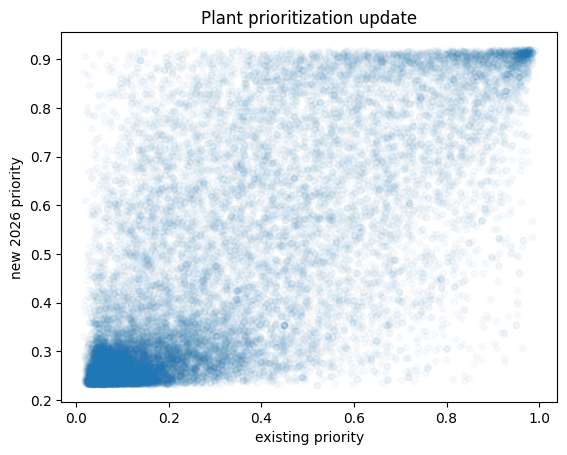

In [ ]:
ax1 = combined_2426.plot.scatter(x="plantrisk_y", y="plant_adj_risk", xlabel='existing priority', ylabel='new 2026 priority', title='Plant prioritization update', alpha=0.03)



In [ ]:
# mean change
(combined_2426['plantrisk_y'] - combined_2426['plantrisk_x']).abs().mean()


0.13440770128491486

In [ ]:
(combined_2426['invertrisk_y'] - combined_2426['invert_adj_risk']).abs().mean()


0.17612101419408605

In [ ]:
(combined_2426['fishrisk_y'] - combined_2426['fish_adj_risk']).abs().mean()


0.565775247662864

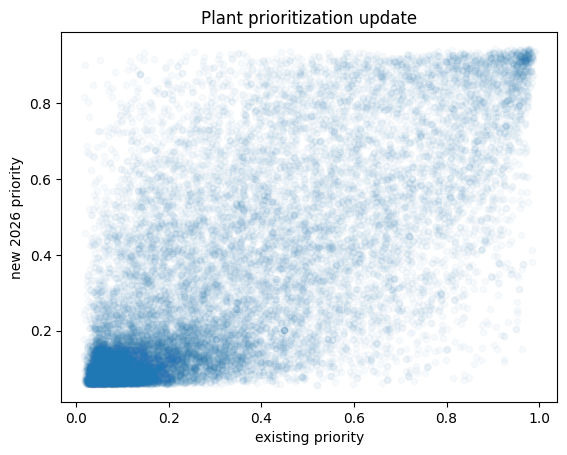

In [ ]:
ax1 = combined_2426.plot.scatter(x="plantrisk_y", y="plantrisk_x", xlabel='existing priority', ylabel='new 2026 priority', title='Plant prioritization update', alpha=0.03)


In [ ]:
combined_2526 = pd.merge(risks_2026, risks_2025, on='lagoslakeid', how='left')

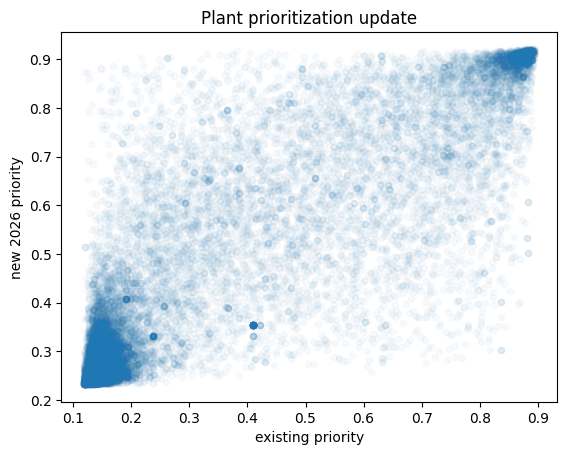

In [ ]:
ax1 = combined_2526.plot.scatter(x="plant_adj_risk_y", y="plant_adj_risk_x", xlabel='existing priority', ylabel='new 2026 priority', title='Plant prioritization update', alpha=0.03)


In [ ]:
(combined_2526['plant_adj_risk_x'] - combined_2526['plant_adj_risk_y']).abs().mean()

0.14201494687830737

In [ ]:
combined_2425 = pd.merge(risks_2024, risks_2025, on='lagoslakeid', how='left')

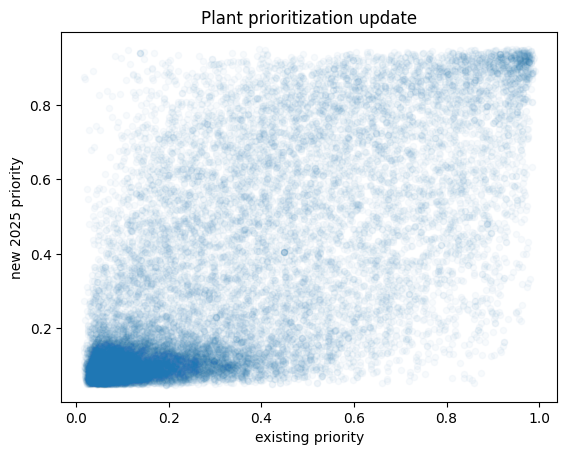

In [ ]:
ax1 = combined_2425.plot.scatter(x="plantrisk_x", y="plantrisk_y", xlabel='existing priority', ylabel='new 2025 priority', title='Plant prioritization update', alpha=0.03)


In [ ]:
plantlakes_2025 = pd.read_csv('/content/drive/My Drive/iedrr/final_inputs_Jan2025/plant_lakes_inv_20250118.csv')
plantlakes_2026 = pd.read_csv('plant_lakes_inv_20260208.csv')

In [ ]:
len(plantlakes_2025)

957

In [ ]:
len(plantlakes_2026)

969

In [ ]:
common_rows_df = pd.merge(plantlakes_2025, plantlakes_2026, how='inner', on=list(plantlakes_2025.columns))


In [ ]:
len(common_rows_df)

230

In [ ]:
plantlakes_2025

,lagoslakeid,year,fold,inv
0,20571.0,1975,0,1
1,48184.0,1977,0,1
2,7326.0,1977,0,1
3,46117.0,1977,0,1
4,29301.0,1977,0,1
...,...,...,...,...
952,49176.0,2024,4,1
953,50036.0,2023,4,1
954,50429.0,2024,4,1
955,51285.0,2023,4,1


In [ ]:
plantlakes_2026

,lagoslakeid,year,fold,inv
0,31123.0,1973,0,1
1,34487.0,1974,0,1
2,20571.0,1975,0,1
3,29301.0,1977,0,1
4,48184.0,1977,0,1
...,...,...,...,...
964,49176.0,2024,4,1
965,50223.0,2025,4,1
966,50429.0,2024,4,1
967,52078.0,2025,4,1
